<h1><center> Data Driven Prediction of Mechanical Properties in Additive Manufactured Alloy </center></h1>

# Preprocessing Data

In [2]:
import pandas as pd

In [3]:
# Import excel data
path = r'C:\Users\26611\Downloads\Process Parameters and Properties LPBF - HV UTS YS BDTD.xlsx'
dataset = pd.read_excel(path)

# Change treatment title - optional
dataset.rename(columns={'Treated (HIP/Y/N)':'Treatment Information'}, inplace=True)
column_names = dataset.columns

dataset

,Material,Author's \nLast Name,Year,Link to paper,Manufacturer,Model,Printing Method,Method,Powder Size \nDistribution (μm),Laser Power (W),...,Fatigue Life (Cycles),Test Temerature (℃).2,Average Work Hardening,Surface Roughness (μm),Error.6,Average Grain Size (μm),Porosity Type,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,316L,Simson,2017.0,https://www.sciencedirect.com/science/article/...,Concept Laser,Mlab cusing,LPBF,NaN,NaN,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lack of Fusion,NaN,NaN,NaN
1,316L,Simson,2017.0,NaN,Concept Laser,Mlab cusing,LPBF,NaN,NaN,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Gas,NaN,NaN,NaN
2,316L,Simson,2017.0,NaN,Renishaw,AM250,LPBF,NaN,NaN,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Gas,NaN,NaN,NaN
3,316L,Simson,2017.0,NaN,Renishaw,AM250,LPBF,NaN,NaN,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Gas,NaN,NaN,NaN
4,316L,Zhong,2016.0,https://www.sciencedirect.com/science/article/...,SLM Solutions,Co D280,LPBF,NaN,NaN,200.0,...,NaN,NaN,2.183673,NaN,NaN,NaN,Gas,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,316L,Greco,2020.0,NaN,NaN,NaN,NaN,Nitrogen,NaN,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
919,316L,Greco,2020.0,NaN,NaN,NaN,NaN,Nitrogen,NaN,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
920,316L,Greco,2020.0,NaN,NaN,NaN,NaN,Nitrogen,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
921,316L,Greco,2020.0,NaN,NaN,NaN,NaN,Nitrogen,NaN,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dataset.columns

Index(['Material', 'Author's \nLast Name', 'Year', 'Link to paper',
       'Manufacturer', 'Model', 'Printing Method', 'Method',
       'Powder Size \nDistribution (μm)', 'Laser Power (W)',
       'Scanning Speed (mm/s)', 'Wire feeding speed (mm/min)',
       'Layer Thickness (um)', 'Hatch Spacing (um)', 'Beam Size (um)',
       'Focus Offset (mm)', 'Scanning strategy', 'layer rotation (degree)',
       'Island/Stripe size (mm)', 'Building Direction',
       'Build plate temperature (°C)', 'Width (um)', 'Height (um)',
       'Depth (um)', 'Area', 'Linear energy density\n(J/m)',
       'Area energy density (J/mm2)', 'Volumetric energy density (J/mm3)',
       'Density measurement method', 'Consolidation (%)', 'Error',
       'Treatment Information', 'Temperature (°C)', 'Time (Hrs)',
       'Pressure (MPa)', 'Cooling', 'Temperature 2 (°C)', 'Time 2 (Hrs)',
       'Cooling.1', 'Temperature 3 (°C)', 'Time 3 (Hrs)', 'Cooling.2',
       'Temperature 4 (°C)', 'Time 4 (Hrs)', 'Cooling.3', 'Tes

In [5]:
dataset[['Material','TD Hardness (HV)']].dropna()

,Material,TD Hardness (HV)
43,316L,255.00
44,316L,221.00
47,316L,217.00
48,316L,212.00
156,316L,230.00
...,...,...
835,316L,258.11
836,316L,251.40
837,316L,254.89
841,316L,226.00


In [6]:
# Specify list of variables we want in our histogram
col_var = [
             'Laser Power (W)',
             'Scanning Speed (mm/s)',
             'Layer Thickness (um)',
             'Hatch Spacing (um)',
             'Beam Size (um)',
             'BD Hardness (HV)',
             'TD Hardness (HV)',
             'BD Yield Stress (MPa)',
             'TD Yield Stress (MPa)',
             'BD Ultimate Tensile Stress (MPa)', 
             'TD Ultimate Tensile Stress (MPa)', 
             'BD Elongation (%)',
             'TD Elongation (%)',
             'Consolidation (%)',]


# Searches selected variable's index number
col_index = []
for i in range(len(col_var)): 
    col_index.append(column_names.get_loc(col_var[i]))

# Converts whole dataset to df and filters necessary columns 
dataset = dataset[dataset.columns[col_index]]
dataset

,Laser Power (W),Scanning Speed (mm/s),Layer Thickness (um),Hatch Spacing (um),Beam Size (um),BD Hardness (HV),TD Hardness (HV),BD Yield Stress (MPa),TD Yield Stress (MPa),BD Ultimate Tensile Stress (MPa),TD Ultimate Tensile Stress (MPa),BD Elongation (%),TD Elongation (%),Consolidation (%)
0,90.0,1500.0,25.0,56.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.828000
1,90.0,600.0,25.0,84.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.524000
2,90.0,300.0,45.0,84.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.388000
3,90.0,300.0,25.0,84.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.887000
4,200.0,1000.0,50.0,80.0,75.0,NaN,NaN,487.0,NaN,594.0,NaN,49.0,NaN,99.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,80.0,343.0,35.0,56.0,50.0,271.658538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.601308
919,90.0,386.0,35.0,56.0,50.0,261.512195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.248368
920,30.0,100.0,45.0,56.0,50.0,265.609756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.686276
921,50.0,167.0,45.0,56.0,50.0,267.463413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.908497


In [7]:
# Use df_hist to see total frequencies
df_hist = dataset.count()
df_hist

Laser Power (W)                     900
Scanning Speed (mm/s)               897
Layer Thickness (um)                903
Hatch Spacing (um)                  828
Beam Size (um)                      477
BD Hardness (HV)                    310
TD Hardness (HV)                     89
BD Yield Stress (MPa)               352
TD Yield Stress (MPa)                73
BD Ultimate Tensile Stress (MPa)    366
TD Ultimate Tensile Stress (MPa)     86
BD Elongation (%)                   389
TD Elongation (%)                    17
Consolidation (%)                   661
dtype: int64

# Histogram of all data

In [8]:
import matplotlib.pyplot as plt
from textwrap import wrap

In [9]:
# Bold font for plots
from matplotlib import rc,rcParams
rc('font', weight='bold')

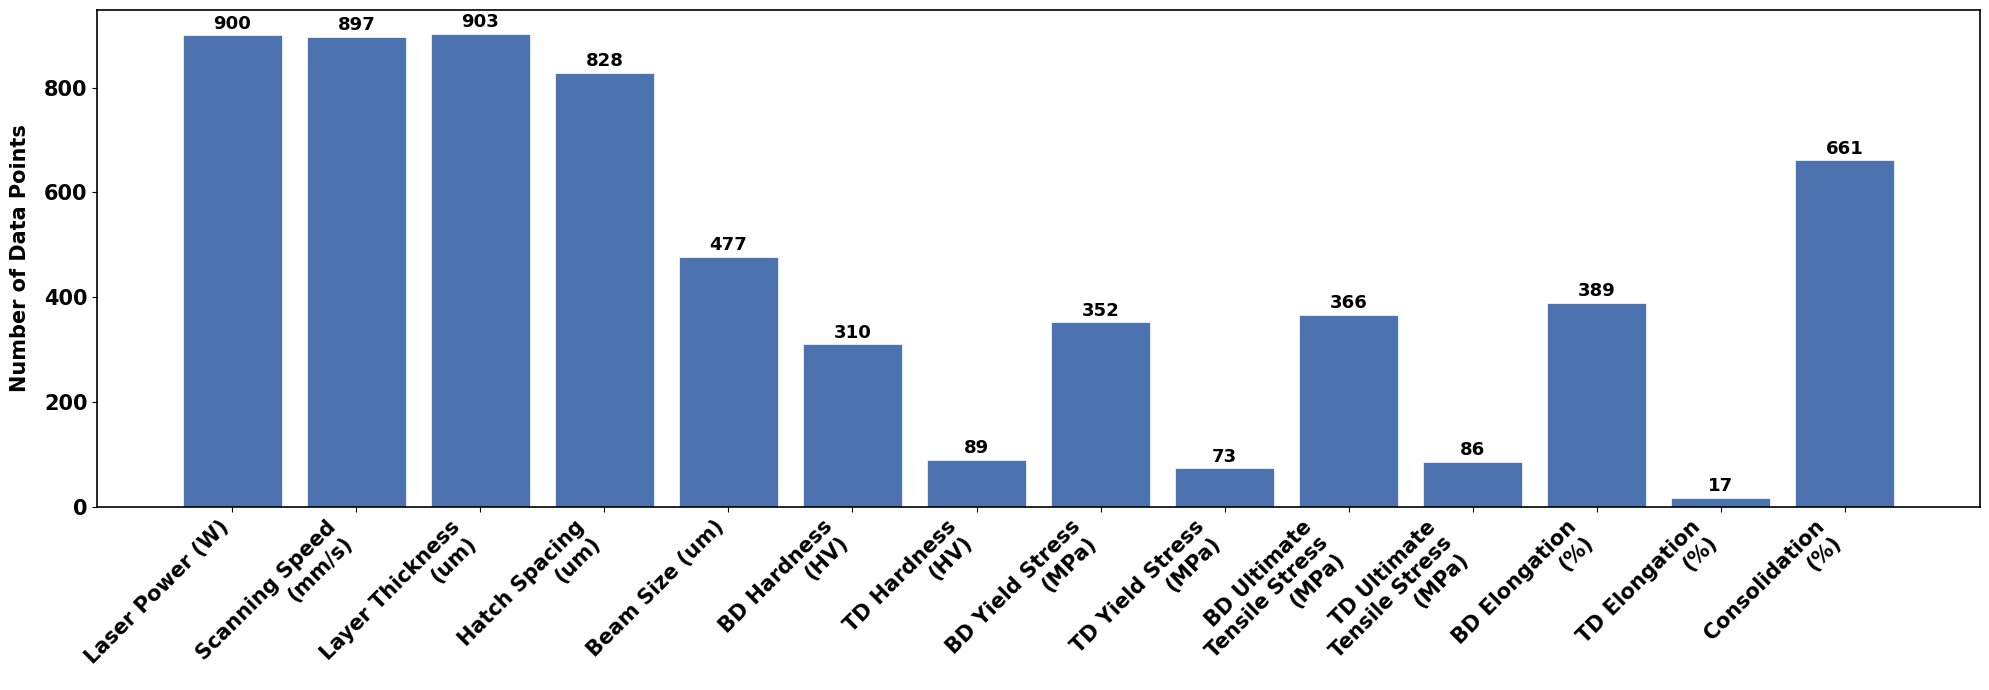

In [16]:
# Plotting histogram for selected variables
cols = dataset[col_var].columns
counts = dataset[col_var].notna().sum()
labs = ['\n'.join(wrap(s, 15)) for s in cols]

f, ax = plt.subplots(1, 1, figsize=(20, 7), facecolor='white')
ax.set_facecolor('white')

bars = ax.bar(range(len(counts)), counts.values, color='#4c72b0', edgecolor='white', linewidth=0.5)

# Numbers on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=13, fontweight='bold')

# Show ALL x labels
ax.set_xticks(range(len(labs)))
ax.set_xticklabels(labs, fontsize=15, rotation=45, ha='right')
ax.set_ylabel('Number of Data Points', fontsize= 15, weight='bold', labelpad=10)
ax.yticks if False else plt.yticks(fontsize=15)

# Black frame
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

ax.grid(False)
plt.tight_layout()
plt.show()

# Histogram of individial variables

In [21]:
import numpy as np

In [22]:
# Choose variables to consider (for input and output data)

input_var = ['Laser Power (W)',
             'Scanning Speed (mm/s)',
             'Layer Thickness (um)',
             'Hatch Spacing (um)',
             'Volumetric energy density (J/mm3)']

output_var = ['BD Hardness (HV)',
              'TD Hardness (HV)',
              'BD Yield Stress (MPa)',
              'TD Yield Stress (MPa)',
              'BD Ultimate Tensile Stress (MPa)', 
              'TD Ultimate Tensile Stress (MPa)', 
              'BD Elongation (%)',
              'TD Elongation (%)',
              'Consolidation (%)']

# Obtains length of input and outputs
n_inputs = len(input_var)
n_outputs = len(output_var)

In [24]:
dataset = pd.read_excel(path)
# Split data into processing parameters and properties (input and output)
x_df = dataset[input_var]
y_df = dataset[output_var]

In [25]:
x_df

,Laser Power (W),Scanning Speed (mm/s),Layer Thickness (um),Hatch Spacing (um),Volumetric energy density (J/mm3)
0,90.0,1500.0,25.0,56.0,48.000000
1,90.0,600.0,25.0,84.0,71.428571
2,90.0,300.0,45.0,84.0,79.365079
3,90.0,300.0,25.0,84.0,142.857143
4,200.0,1000.0,50.0,80.0,50.000000
...,...,...,...,...,...
918,80.0,343.0,35.0,56.0,119.000000
919,90.0,386.0,35.0,56.0,119.000000
920,30.0,100.0,45.0,56.0,119.000000
921,50.0,167.0,45.0,56.0,119.000000


In [26]:
y_df

,BD Hardness (HV),TD Hardness (HV),BD Yield Stress (MPa),TD Yield Stress (MPa),BD Ultimate Tensile Stress (MPa),TD Ultimate Tensile Stress (MPa),BD Elongation (%),TD Elongation (%),Consolidation (%)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.828000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.524000
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.388000
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.887000
4,NaN,NaN,487.0,NaN,594.0,NaN,49.0,NaN,99.800000
...,...,...,...,...,...,...,...,...,...
918,271.658538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.601308
919,261.512195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.248368
920,265.609756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.686276
921,267.463413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.908497


# Distribution Plots

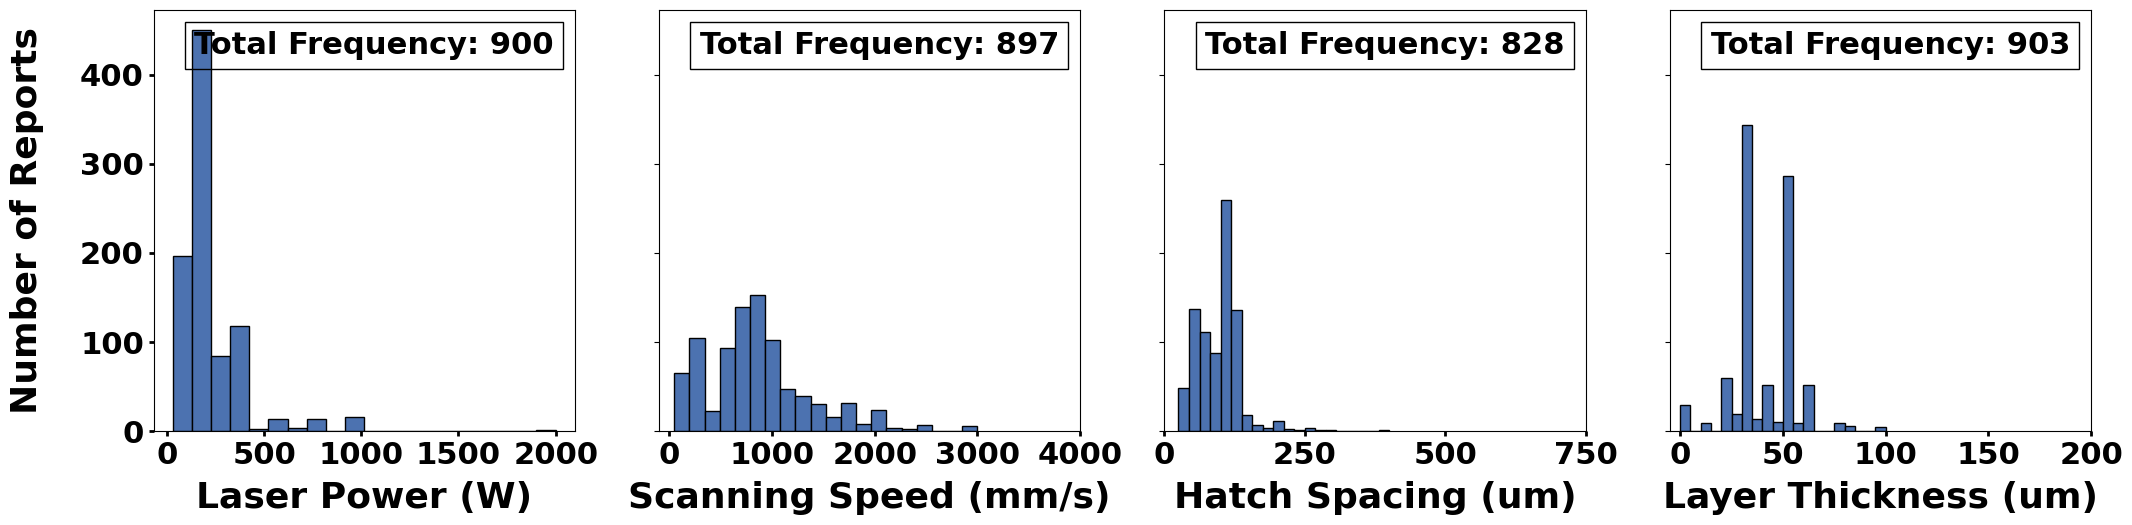

In [27]:
pad_size = 8
txt_size = 26
bins = 20

counts1 = x_df['Laser Power (W)'].count()
counts2 = x_df['Scanning Speed (mm/s)'].count()
counts3 = x_df['Hatch Spacing (um)'].count()
counts4 = x_df['Layer Thickness (um)'].count()

box = {'facecolor': 'none',
       'edgecolor': 'black',
       'boxstyle': 'square'}

fig, ax = plt.subplots(1, 4, figsize=(25, 8), sharey=True)
ax1 = plt.subplot(1, 4, 1)
ax1.hist(x_df['Laser Power (W)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax1.set_xticks(np.linspace(0, 2000, 5))
ax1.set_xlabel('Laser Power (W)', labelpad=pad_size, fontsize = txt_size, weight='bold')
ax1.set_ylabel('Frequency', labelpad=pad_size+5, fontsize = txt_size)
ax1.text(0.95, 0.95, f'Total Frequency: {counts1}', 
         fontsize=22, color='k', ha='right', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='both', which='both', bottom=True, left=True, width=2, labelsize=22)
ax1.set_ylabel('Number of Reports', labelpad=txt_size, weight='bold')

ax2 = plt.subplot(1, 4, 2)
ax2.hist(x_df['Scanning Speed (mm/s)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax2.set_xticks(np.linspace(0, 4000, 5))
ax2.set_xlabel('Scanning Speed (mm/s)', labelpad=pad_size, fontsize = txt_size, weight='bold')
ax2.text(0.95, 0.95, f'Total Frequency: {counts2}', 
         fontsize=22, color='k', ha='right', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='x', which='both', bottom=True, left=True, width=2, labelsize=22)

ax3 = plt.subplot(1, 4, 3)
ax3.hist(x_df['Hatch Spacing (um)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax3.set_xticks(np.linspace(0, 750, 4))
ax3.set_xlabel('Hatch Spacing (um)', labelpad=pad_size, fontsize = txt_size, weight='bold');
ax3.text(0.95, 0.95, f'Total Frequency: {counts3}', 
         fontsize=22, color='k', ha='right', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='x', which='both', bottom=True, left=True, width=2, labelsize=22)

ax4 = plt.subplot(1, 4, 4)
ax4.hist(x_df['Layer Thickness (um)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax4.set_xticks(np.linspace(0, 200, 5))
ax4.set_xlabel('Layer Thickness (um)', labelpad=pad_size, fontsize = txt_size, weight='bold');
ax4.text(0.95, 0.95, f'Total Frequency: {counts4}', 
         fontsize=22, color='k', ha='right', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='x', which='both', bottom=True, left=True, width=2, labelsize=22)

# Fixes figure ratio
x0,x1 = ax1.get_xlim()
y0,y1 = ax1.get_ylim()
ax1.set_aspect(abs(x1-x0)/abs(y1-y0))
x0,x1 = ax2.get_xlim()
y0,y1 = ax2.get_ylim()
ax2.set_aspect(abs(x1-x0)/abs(y1-y0))
x0,x1 = ax3.get_xlim()
y0,y1 = ax3.get_ylim()
ax3.set_aspect(abs(x1-x0)/abs(y1-y0))
x0,x1 = ax4.get_xlim()
y0,y1 = ax4.get_ylim()
ax4.set_aspect(abs(x1-x0)/abs(y1-y0))

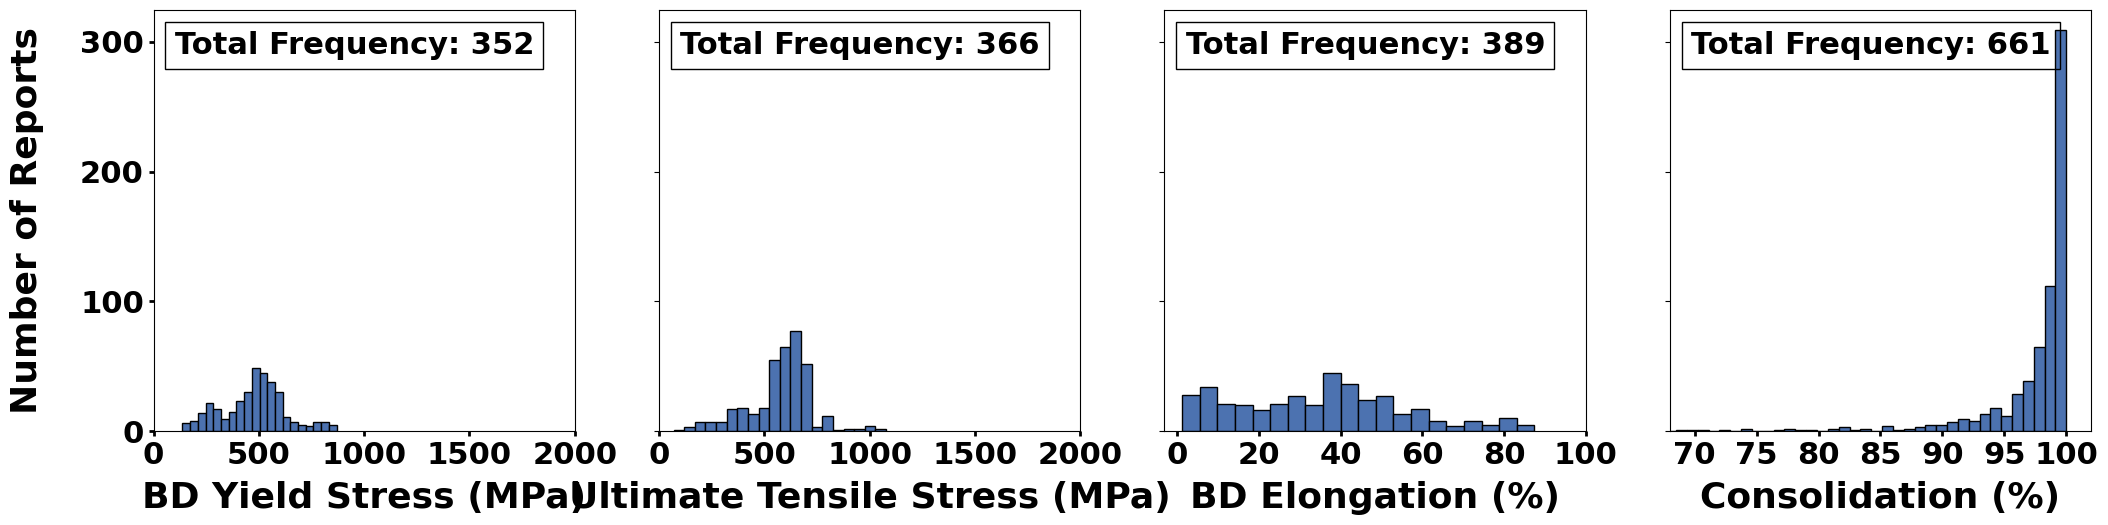

In [28]:
pad_size = 8
txt_size = 26
bins = 20

counts1 = y_df['BD Yield Stress (MPa)'].count()
counts2 = y_df['BD Ultimate Tensile Stress (MPa)'].count()
counts3 = y_df['BD Elongation (%)'].count()
counts4 = y_df['Consolidation (%)'].count()

box = {'facecolor': 'none',
       'edgecolor': 'black',
       'boxstyle': 'square'}

fig, ax = plt.subplots(1, 4, figsize=(25, 8), sharey=True)
ax1 = plt.subplot(1, 4, 1)
ax1.hist(y_df['BD Yield Stress (MPa)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax1.set_xticks(np.linspace(0, 2000,5))
ax1.set_xlabel('BD Yield Stress (MPa)', labelpad=pad_size, fontsize = txt_size, weight='bold')
ax1.set_ylabel('Frequency', labelpad=pad_size, fontsize = txt_size)
ax1.text(0.05, 0.95, f'Total Frequency: {counts1}', 
         fontsize=22, color='k', ha='left', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='both', which='both', bottom=True, left=True, width=2, labelsize=22)
ax1.set_ylabel('Number of Reports', labelpad=txt_size, weight='bold')

ax2 = plt.subplot(1, 4, 2)
ax2.hist(y_df['BD Ultimate Tensile Stress (MPa)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax2.set_xticks(np.linspace(0, 2000, 5))
ax2.set_xlabel('Ultimate Tensile Stress (MPa)', labelpad=pad_size, fontsize = txt_size, weight='bold')
ax2.text(0.05, 0.95, f'Total Frequency: {counts2}', 
         fontsize=22, color='k', ha='left', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='x', which='both', bottom=True, left=True, width=2, labelsize=22)

ax3 = plt.subplot(1, 4, 3)
ax3.hist(y_df['BD Elongation (%)'], bins=bins, color='#4c72b0', edgecolor = 'black');
ax3.set_xticks(np.linspace(0, 100, 6))
ax3.set_xlabel('BD Elongation (%)', labelpad=pad_size, fontsize = txt_size, weight='bold')
ax3.text(0.05, 0.95, f'Total Frequency: {counts3}', 
         fontsize=22, color='k', ha='left', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='x', which='both', bottom=True, left=True, width=2, labelsize=22)

ax4 = plt.subplot(1, 4, 4)
ax4.hist(y_df['Consolidation (%)'], bins=bins+20, color='#4c72b0', edgecolor = 'black');
ax4.set_xticks(np.linspace(70, 100, 7))
ax4.set(xlim=(68, 102))
ax4.set_xlabel('Consolidation (%)', labelpad=pad_size, fontsize = txt_size, weight='bold');
ax4.text(0.05, 0.95, f'Total Frequency: {counts4}', 
         fontsize=22, color='k', ha='left', va='top', bbox=box,
         transform=plt.gca().transAxes);
plt.tick_params(axis='x', which='both', bottom=True, left=True, width=2, labelsize=22)

x0,x1 = ax1.get_xlim()
y0,y1 = ax1.get_ylim()
ax1.set_aspect(abs(x1-x0)/abs(y1-y0))
x0,x1 = ax2.get_xlim()
y0,y1 = ax2.get_ylim()
ax2.set_aspect(abs(x1-x0)/abs(y1-y0))
x0,x1 = ax3.get_xlim()
y0,y1 = ax3.get_ylim()
ax3.set_aspect(abs(x1-x0)/abs(y1-y0))
x0,x1 = ax4.get_xlim()
y0,y1 = ax4.get_ylim()
ax4.set_aspect(abs(x1-x0)/abs(y1-y0))

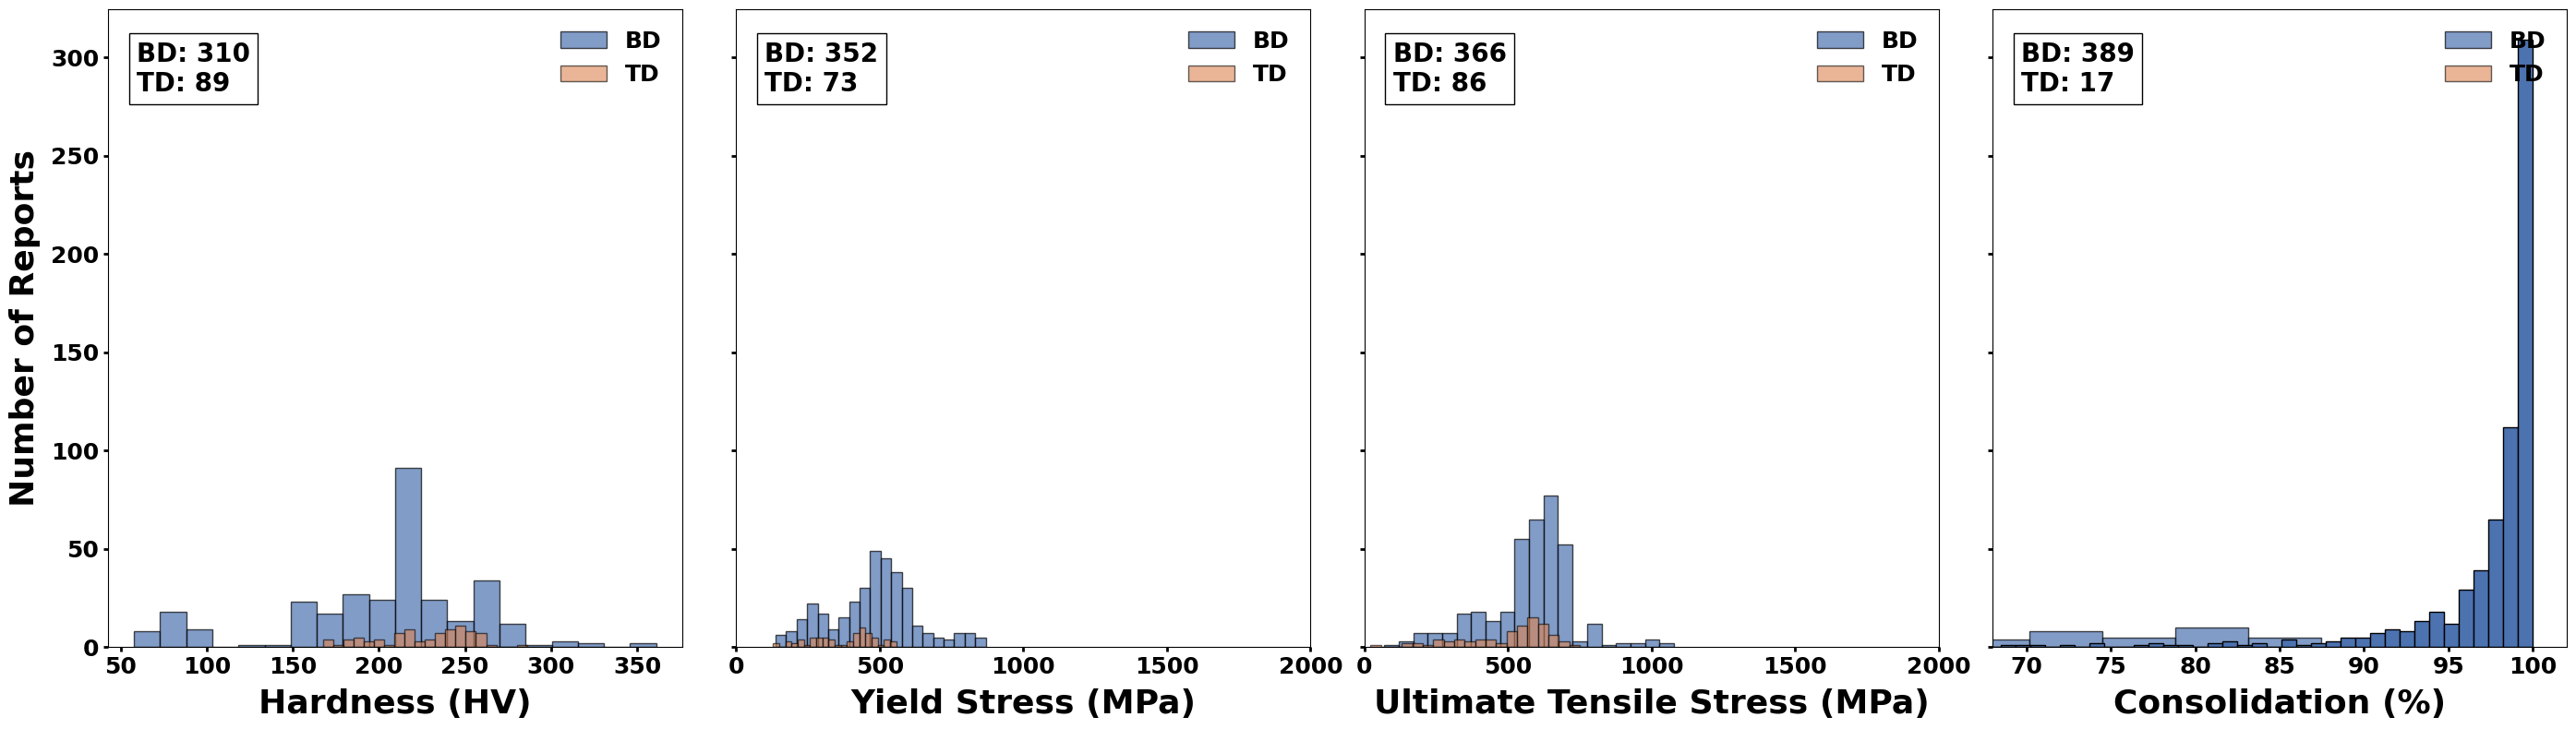

In [18]:
pad_size = 8
txt_size = 26
bins = 20
box = {'facecolor': 'none', 'edgecolor': 'black', 'boxstyle': 'square'}

# Columns for BD/TD pairs
pairs = [ ('BD Hardness (HV)', 'TD Hardness (HV)'),
    ('BD Yield Stress (MPa)', 'TD Yield Stress (MPa)'),
    ('BD Ultimate Tensile Stress (MPa)', 'TD Ultimate Tensile Stress (MPa)'),
    ('BD Elongation (%)', 'TD Elongation (%)'),
]
# Single column for consolidation
single = 'Consolidation (%)'

# Figure setup
fig, axes = plt.subplots(1, 4, figsize=(28, 8), sharey=True)

colors = ['#4c72b0', '#dd8452']  # BD = blue, TD = orange

for i, (bd_col, td_col) in enumerate(pairs):
    ax = axes[i]
    bd_data = y_df[bd_col].dropna()
    td_data = y_df[td_col].dropna()

    ax.hist(bd_data, bins=bins, color=colors[0], alpha=0.7, label='BD', edgecolor='black')
    ax.hist(td_data, bins=bins, color=colors[1], alpha=0.6, label='TD', edgecolor='black')

    ax.set_xlabel(bd_col.replace('BD ', ''), fontsize=txt_size, labelpad=pad_size, weight='bold')
    if i == 0:
        ax.set_ylabel('Number of Reports', fontsize=txt_size, labelpad=pad_size, weight='bold')

    # Axis ticks
    if 'Stress' in bd_col:
        ax.set_xticks(np.linspace(0, 2000, 5))
        ax.set_xlim(0, 2000)
    elif 'Elongation' in bd_col:
        ax.set_xticks(np.linspace(0, 100, 6))
        ax.set_xlim(0, 100)

    # Frequency box
    total_bd = len(bd_data)
    total_td = len(td_data)
    ax.text(0.05, 0.95, f'BD: {total_bd}\nTD: {total_td}',
            fontsize=20, color='k', ha='left', va='top', bbox=box, transform=ax.transAxes)

    # Add legend to each BD/TD subplot
    ax.legend(fontsize=18, frameon=False, loc='upper right')

    ax.grid(False)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='both', width=2, labelsize=18)

# Consolidation subplot 
ax4 = axes[3]
con_data = y_df[single].dropna()
ax4.hist(con_data, bins=bins+20, color=colors[0], edgecolor='black')
ax4.set_xlabel('Consolidation (%)', fontsize=txt_size, labelpad=pad_size, weight='bold')
ax4.set_xlim(68, 102)
ax4.set_xticks(np.linspace(70, 100, 7))
# ax4.text(0.05, 0.95, f'Total: {len(con_data)}',
         #fontsize=20, color='k', ha='left', bbox=box, transform=ax4.transAxes)
ax4.grid(False)
ax4.set_facecolor('white')
ax4.tick_params(axis='both', which='both', width=2, labelsize=18)

plt.tight_layout()
plt.show()

In [19]:
# Count percentage of consolidation values above 95%
consol_df = y_df['Consolidation (%)']
consol_df = consol_df.dropna()
consol_df = consol_df.reset_index(drop=True)
counter = 0

for i in range(len(consol_df)):
    if consol_df[i] >= 95:
        counter = counter+1

print("Percentage of reports >= 95%:")
print((counter/len(consol_df))*100)

Percentage of reports >= 95%:
84.72012102874432


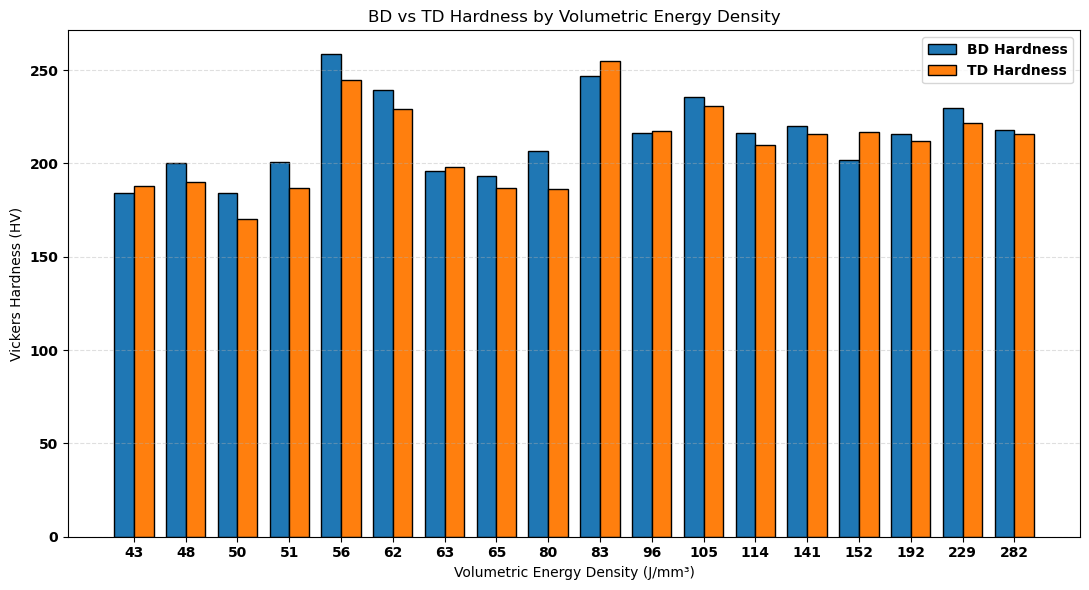

In [21]:
df = dataset.copy()

# 1) Ensure numeric
cols = ['Volumetric energy density (J/mm3)', 'BD Hardness (HV)', 'TD Hardness (HV)']
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 2)  round/bucket VED to merge tiny float diffs
df['VED'] = df['Volumetric energy density (J/mm3)'].round(0)  # or round(1)

# Drop rows missing essentials
df = df.dropna(subset=['VED', 'BD Hardness (HV)', 'TD Hardness (HV)'])

# Aggregate: mean (and std for optional error bars)
agg = df.groupby('VED').agg(
    BD_mean=('BD Hardness (HV)', 'mean'),
    BD_std =('BD Hardness (HV)', 'std'),
    TD_mean=('TD Hardness (HV)', 'mean'),
    TD_std =('TD Hardness (HV)', 'std')
).reset_index().sort_values('VED')

# 3) Plot grouped bars (one group per VED)
x = np.arange(len(agg))
w = 0.38

fig, ax = plt.subplots(figsize=(11,6))
bd = ax.bar(x - w/2, agg['BD_mean'], w, label='BD Hardness', edgecolor='black')
td = ax.bar(x + w/2, agg['TD_mean'], w, label='TD Hardness', edgecolor='black')

ax.set_xlabel('Volumetric Energy Density (J/mm³)')
ax.set_ylabel('Vickers Hardness (HV)')
ax.set_title('BD vs TD Hardness by Volumetric Energy Density')
ax.set_xticks(x)
ax.set_xticklabels(agg['VED'].astype(int), rotation=0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


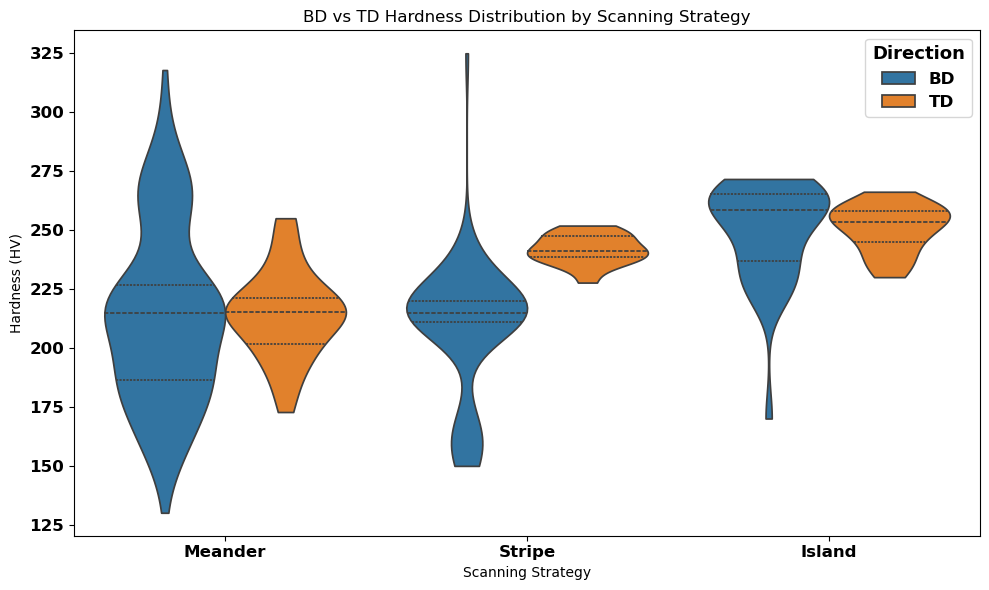

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

strategy_col = 'Scanning strategy'

# 1) Convert to long format
df_long = dataset.melt(
    id_vars=[strategy_col],
    value_vars=['BD Hardness (HV)', 'TD Hardness (HV)'],
    var_name='Direction',
    value_name='Hardness (HV)'
)

df_long['Direction'] = df_long['Direction'].replace({
    'BD Hardness (HV)': 'BD',
    'TD Hardness (HV)': 'TD'
})

order = ['Meander', 'Stripe', 'Island']
df_long[strategy_col] = pd.Categorical(df_long[strategy_col], categories=order, ordered=True)

# 2) Plot (side-by-side violins with quartiles)
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_long,
    x=strategy_col,
    y='Hardness (HV)',
    hue='Direction',
    inner='quartile',
    cut=0,
    density_norm='width',
    dodge=True
)

plt.title('BD vs TD Hardness Distribution by Scanning Strategy')
plt.xlabel('Scanning Strategy')
plt.ylabel('Hardness (HV)')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(title='Direction', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()

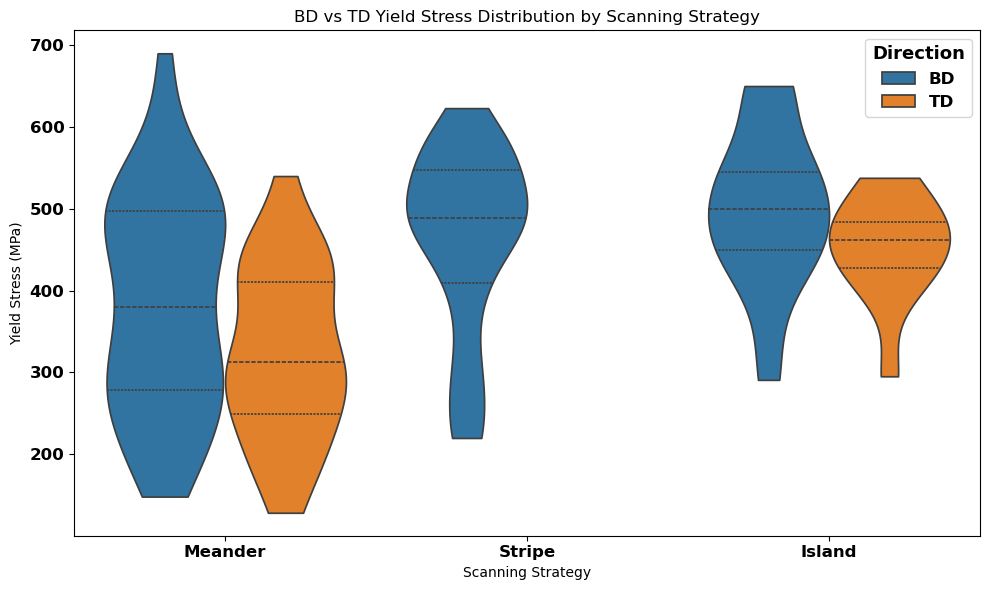

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

strategy_col = 'Scanning strategy'

# 1) Convert to long format
df_long = dataset.melt(
    id_vars=[strategy_col],
    value_vars=['BD Yield Stress (MPa)', 'TD Yield Stress (MPa)'],
    var_name='Direction',
    value_name='Yield Stress (MPa)'
)

df_long['Direction'] = df_long['Direction'].replace({
    'BD Yield Stress (MPa)': 'BD',
    'TD Yield Stress (MPa)': 'TD'
})

order = ['Meander', 'Stripe', 'Island']
df_long[strategy_col] = pd.Categorical(df_long[strategy_col], categories=order, ordered=True)

# 2) Plot (side-by-side violins with quartiles)
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_long,
    x=strategy_col,
    y='Yield Stress (MPa)',
    hue='Direction',
    inner='quartile',
    cut=0,
    density_norm='width',
    dodge=True
)

plt.title('BD vs TD Yield Stress Distribution by Scanning Strategy')
plt.xlabel('Scanning Strategy')
plt.ylabel('Yield Stress (MPa)')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(title='Direction', fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.show()

# Pairwise Relationship

In [18]:
import seaborn as sns

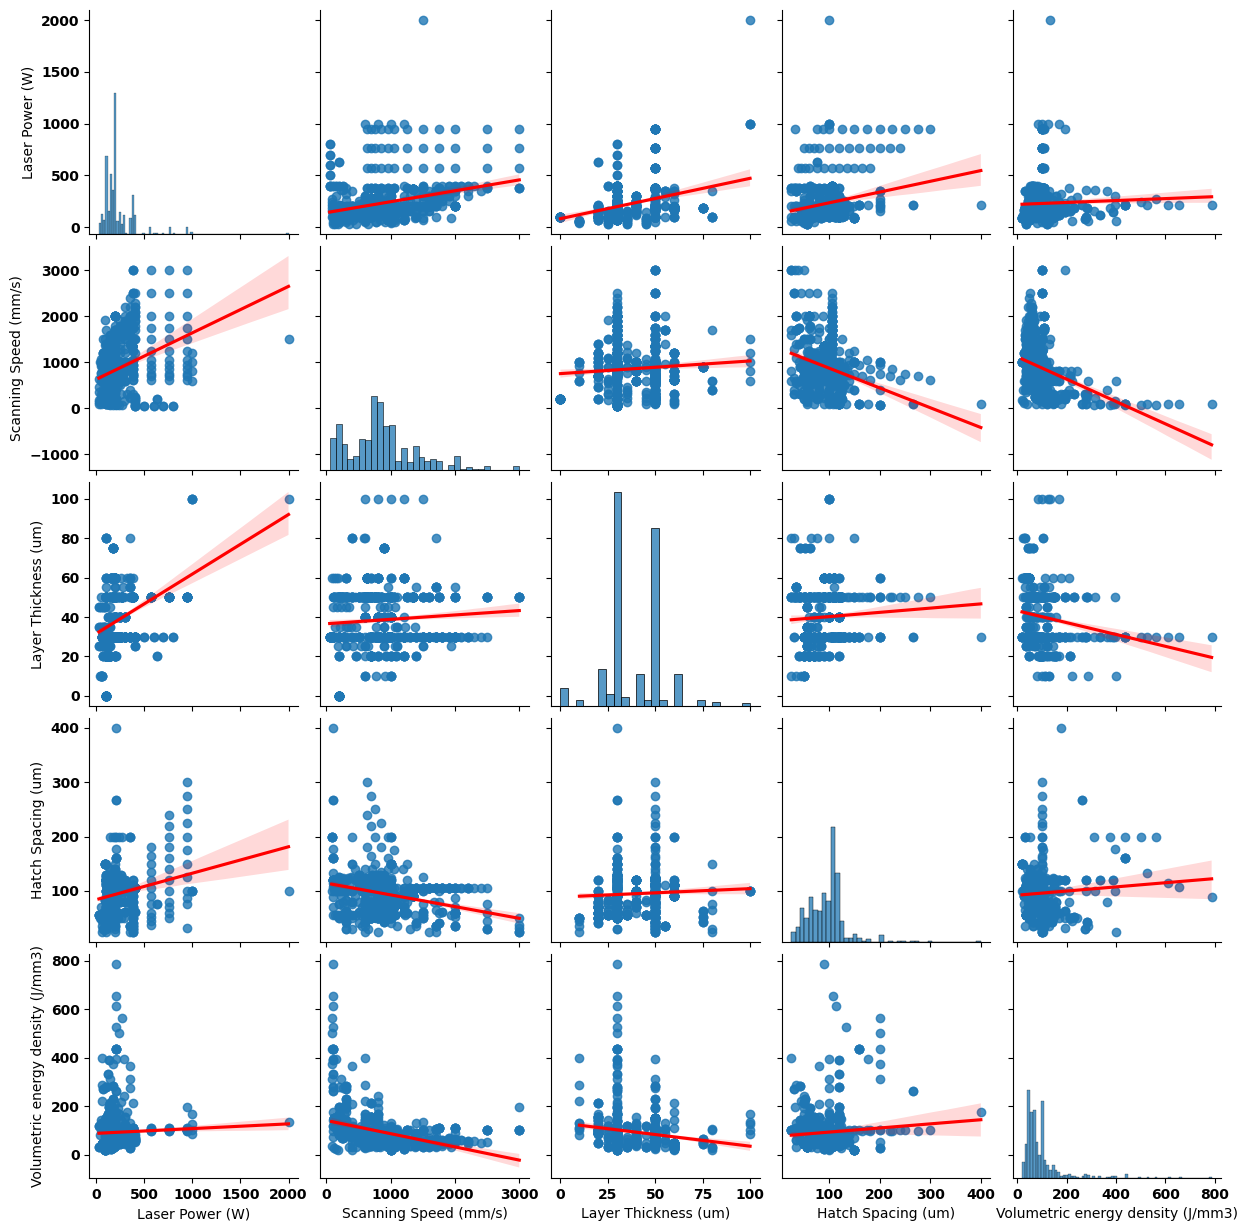

In [25]:
# Plot pairwise relationship - inputs
sns.pairplot(x_df, kind="reg", plot_kws={'line_kws':{'color':'red'}})

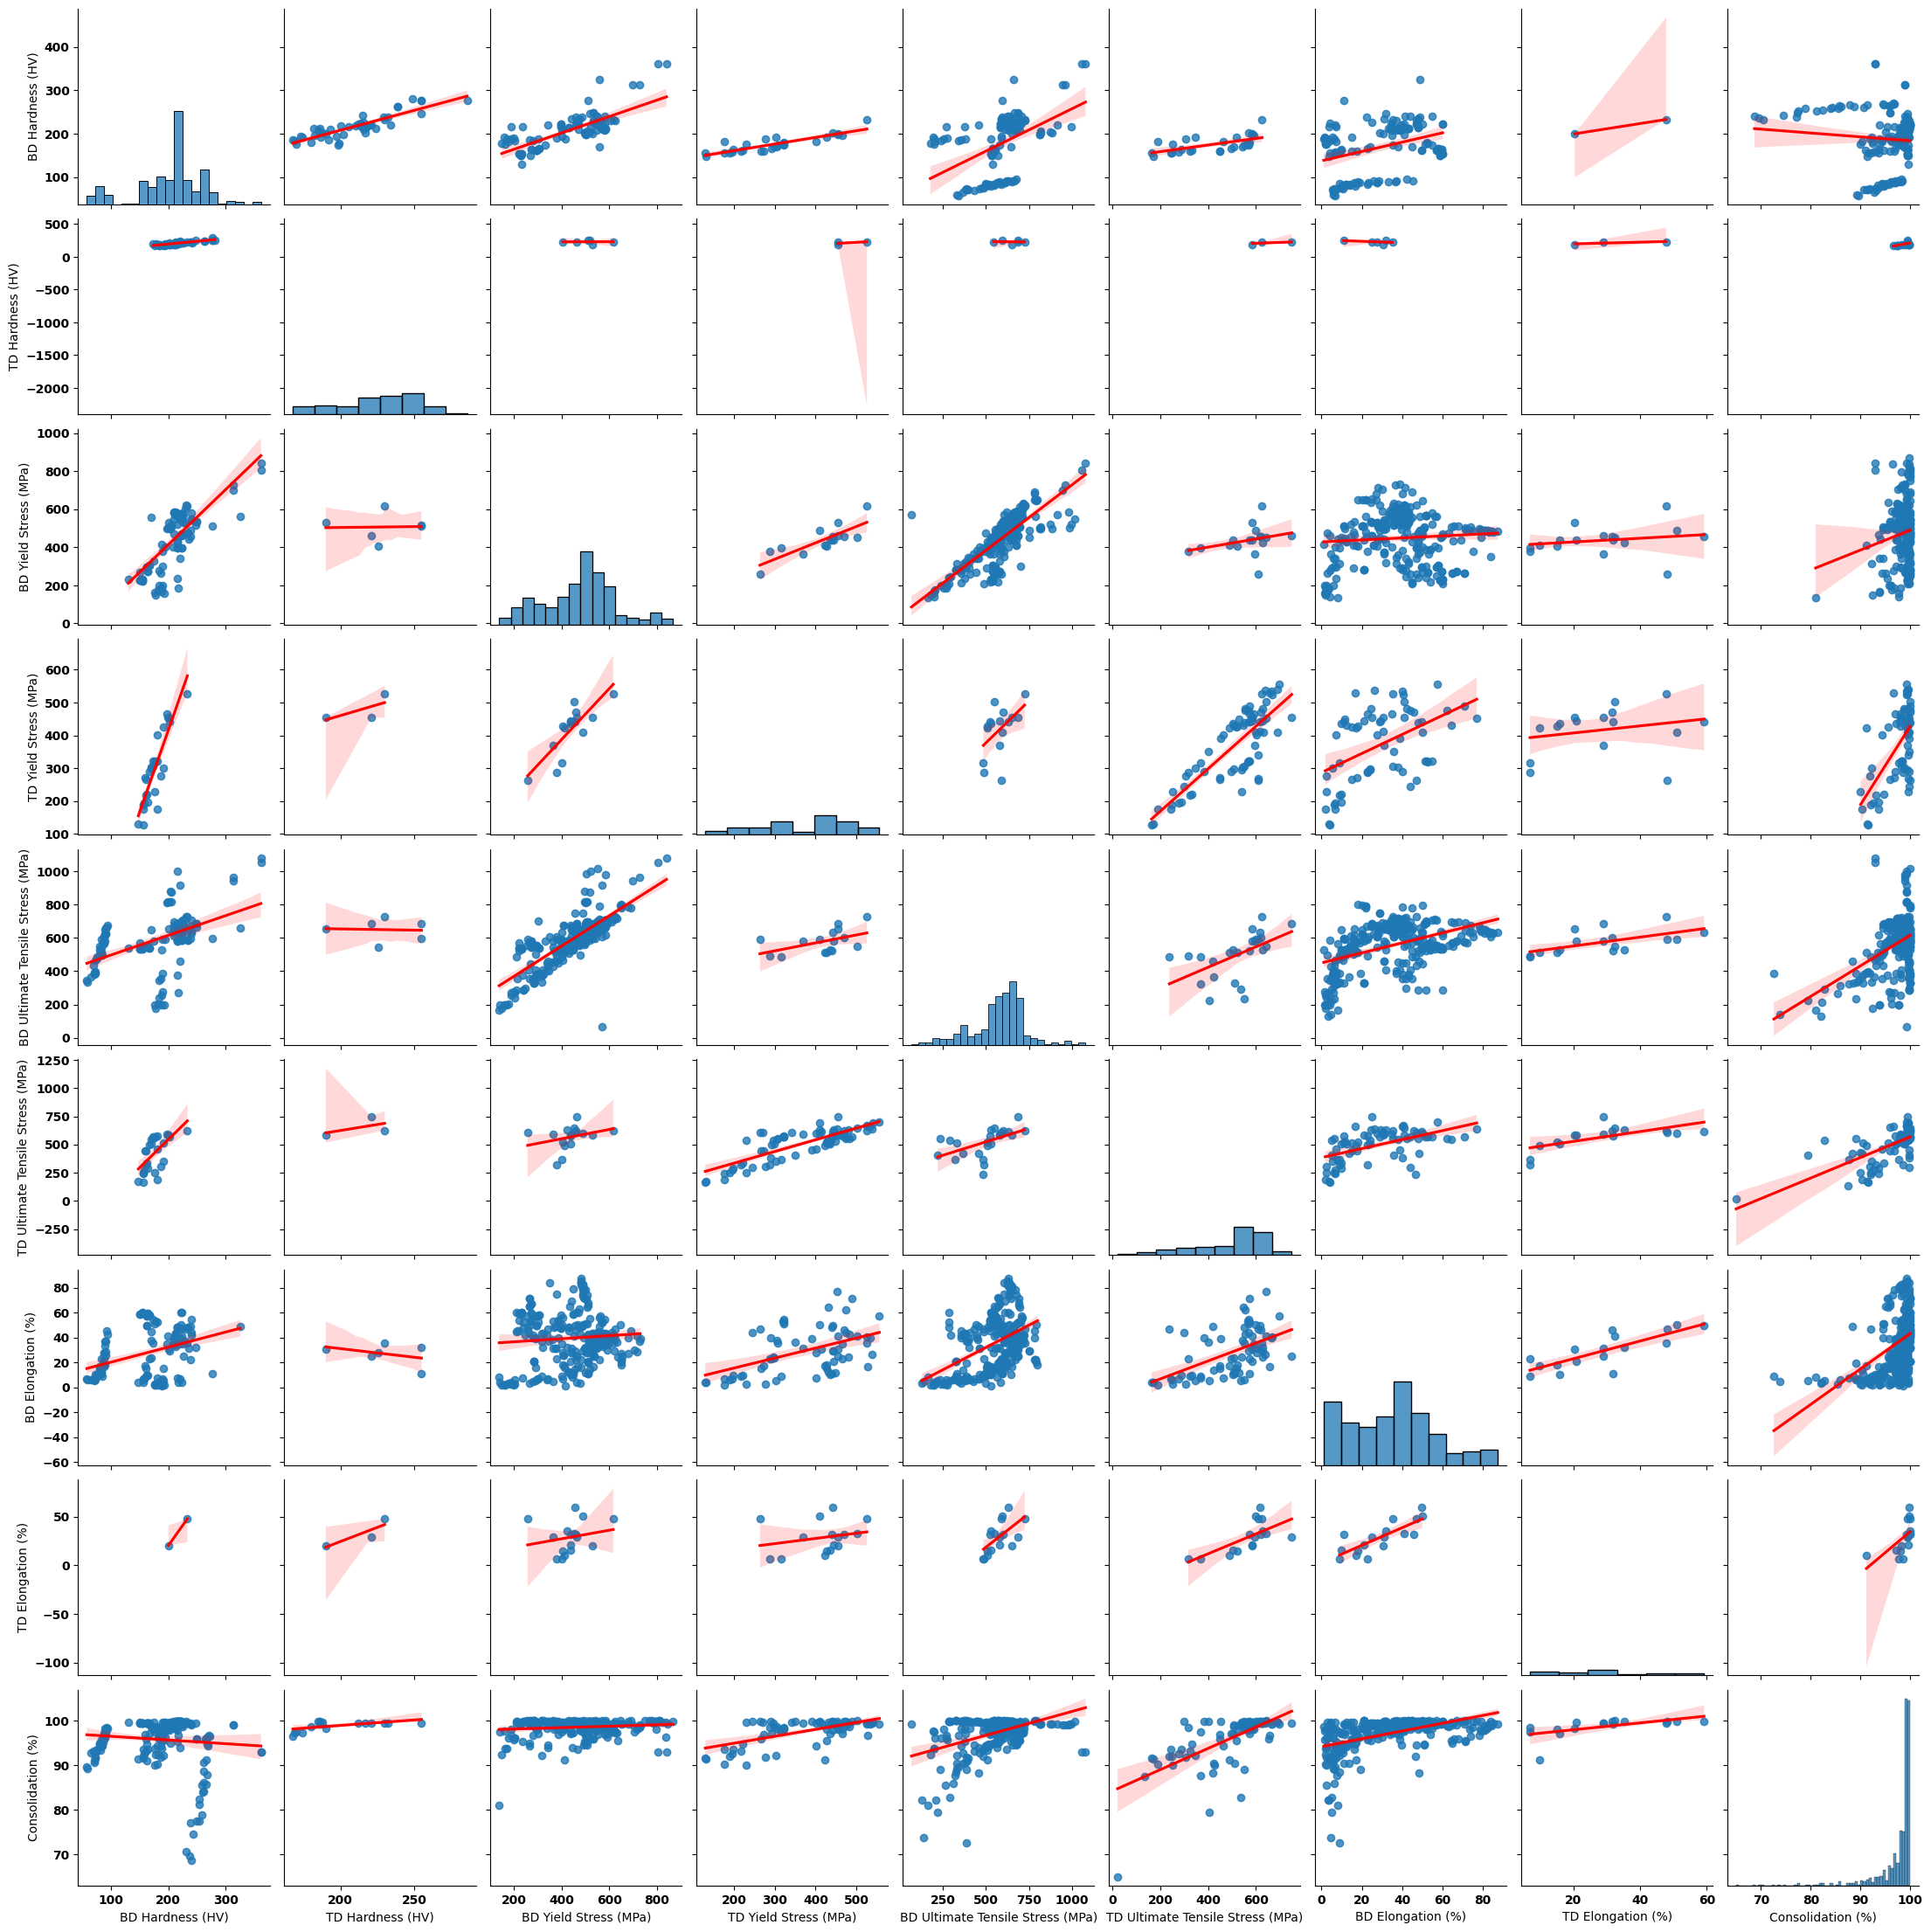

In [26]:
# Plot pairwise relationship - outputs
sns.pairplot(y_df, kind="reg", plot_kws={'line_kws':{'color':'red'}})

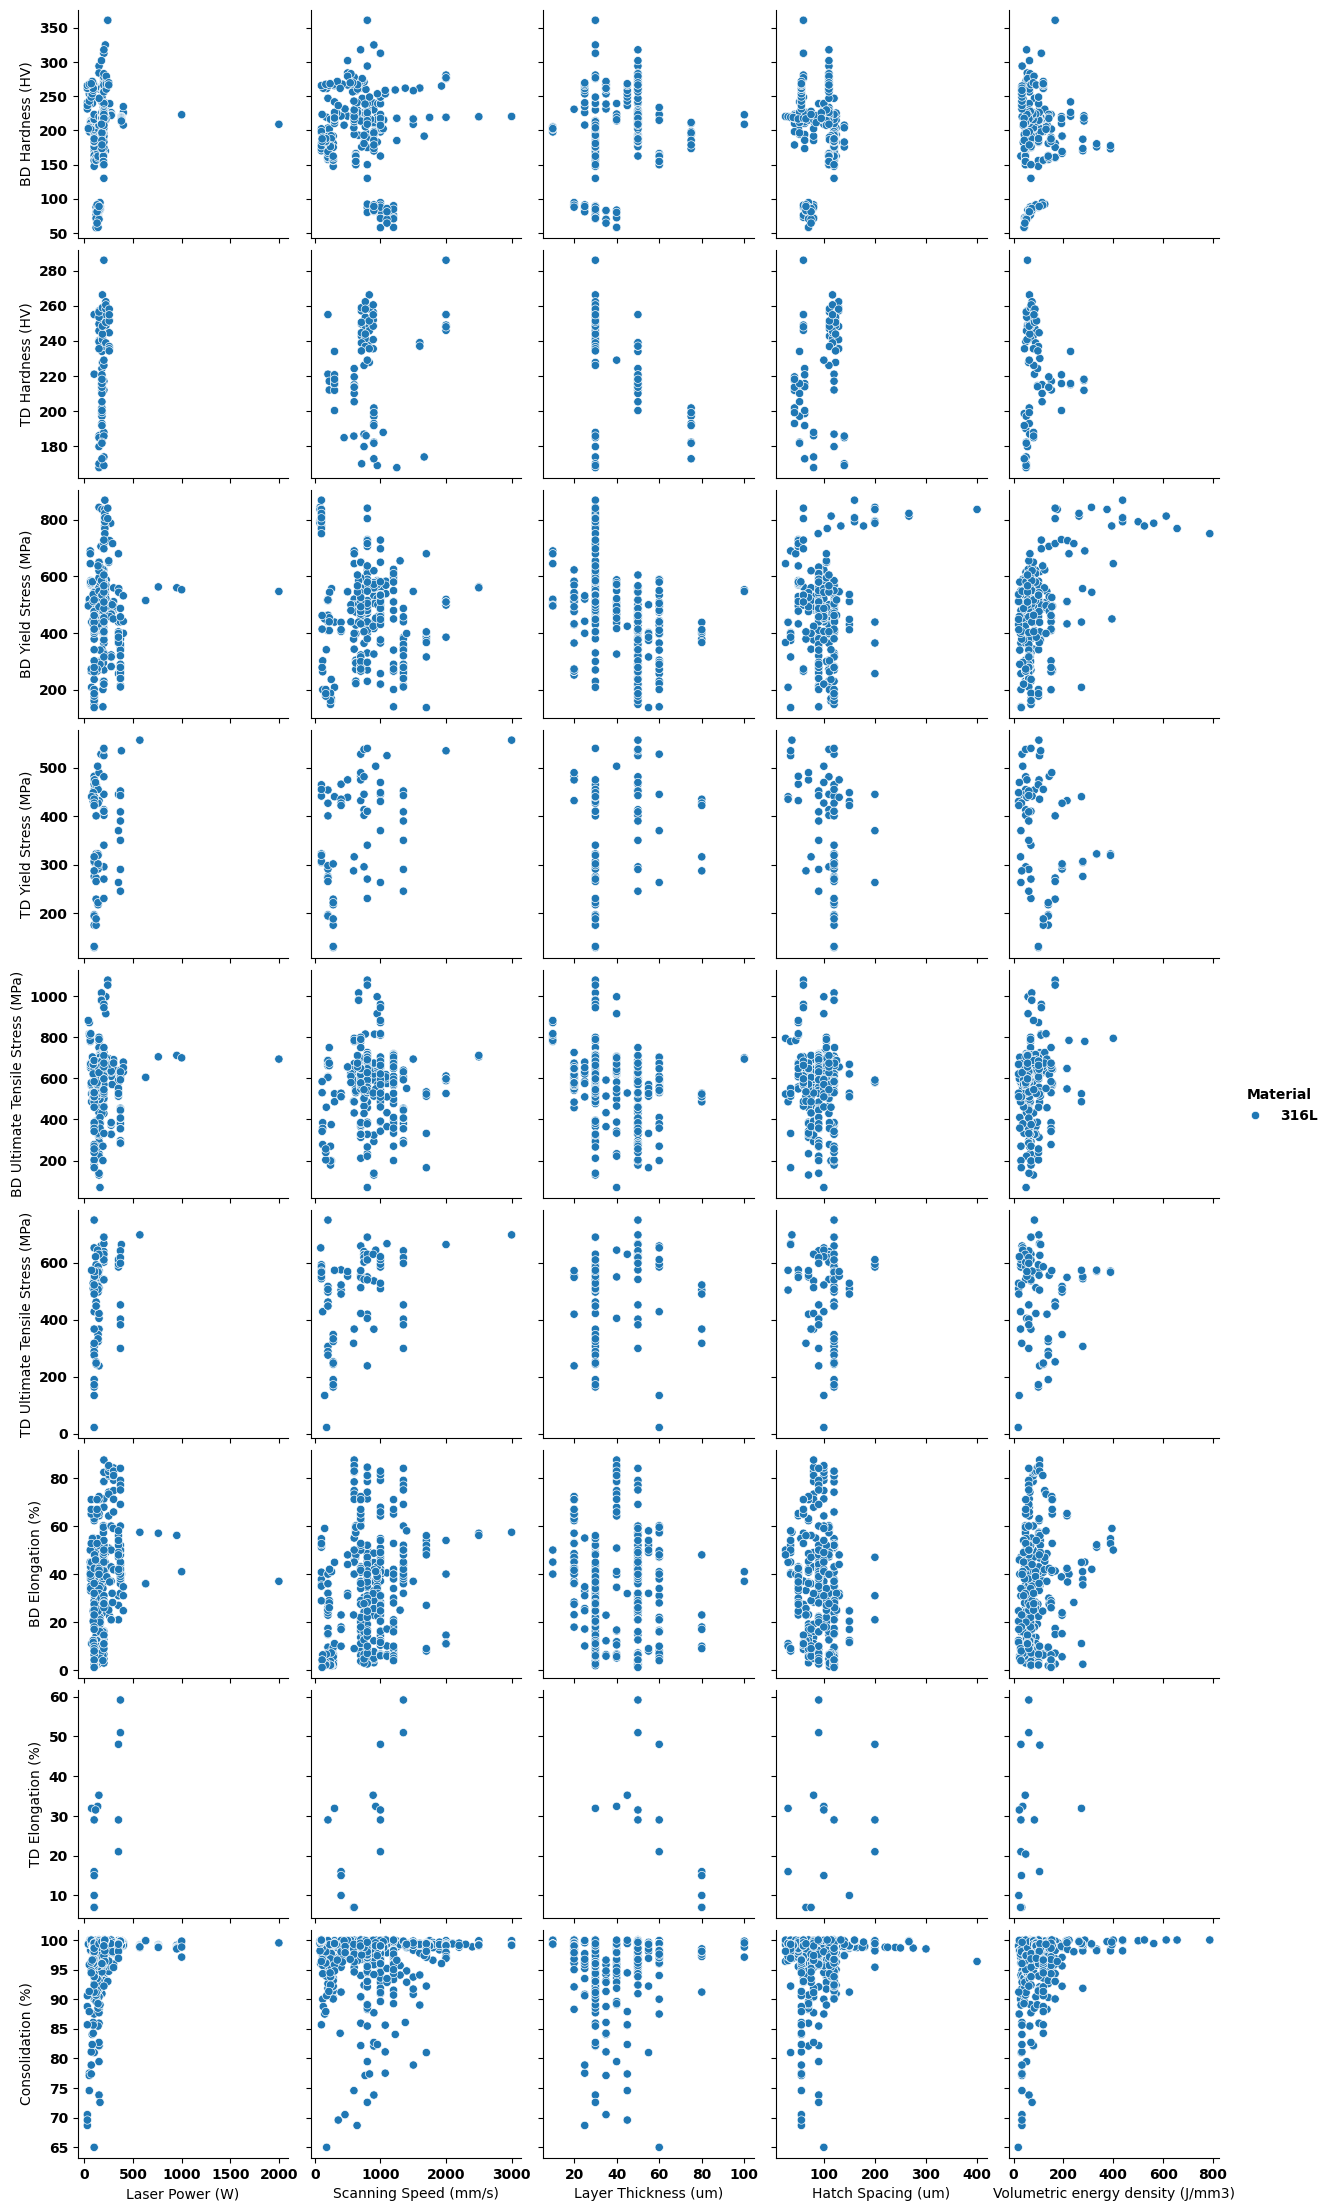

In [27]:
# Plot pairwise relationship - inputs to outputs
sns.pairplot(data=dataset, x_vars=input_var, y_vars=output_var, hue="Material")

Total data points: 651
VED range: 18.5 - 787.5 J/mm³
Consolidation range: 65.00 - 100.00%


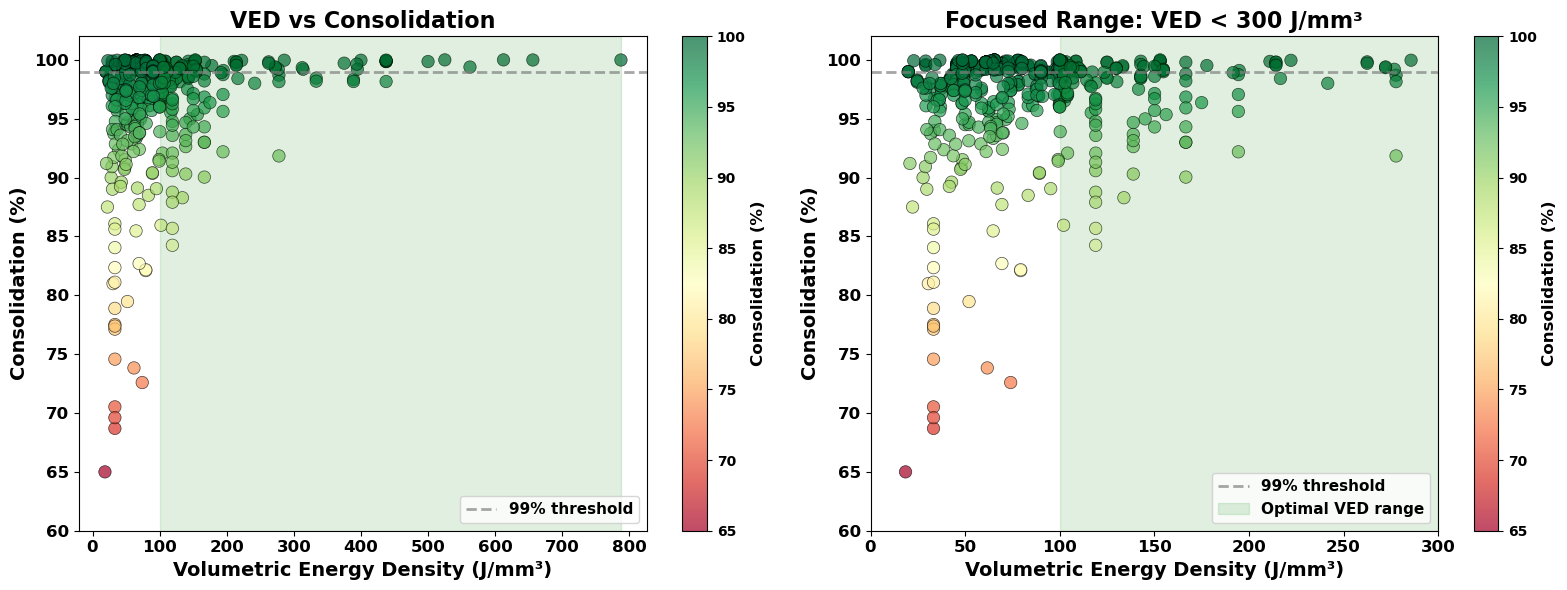


CONSOLIDATION STATISTICS BY VED RANGE

≥99.0% consolidation:
  VED range: 20.0 - 787.5 J/mm³
  Number of samples: 329
  Practical range (VED<300): 20.0 - 285.7 J/mm³

≥99.5% consolidation:
  VED range: 22.9 - 787.5 J/mm³
  Number of samples: 160
  Practical range (VED<300): 22.9 - 285.7 J/mm³


In [ ]:
# VED vs Consolidation Analysis 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and prepare data
data = dataset[['Material', 'Volumetric energy density (J/mm3)', 'Consolidation (%)']].copy()
data = data[data['Material'].str.contains('316L', na=False, case=False)]
data = data.dropna(subset=['Volumetric energy density (J/mm3)', 'Consolidation (%)'])
data.columns = ['Material', 'VED', 'Consolidation']

print(f"Total data points: {len(data)}")
print(f"VED range: {data['VED'].min():.1f} - {data['VED'].max():.1f} J/mm³")
print(f"Consolidation range: {data['Consolidation'].min():.2f} - {data['Consolidation'].max():.2f}%")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ========== LEFT PLOT: Full Range ==========
scatter1 = ax1.scatter(data['VED'], data['Consolidation'], 
                       c=data['Consolidation'], cmap='RdYlGn', 
                       s=80, alpha=0.7, edgecolors='black', linewidth=0.5, vmin=65, vmax=100)

# Add 99% threshold line
ax1.axhline(99, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='99% threshold')

# Add optimal zone shading
ax1.axvspan(100, data['VED'].max(), alpha=0.12, color='green')

ax1.set_xlabel('Volumetric Energy Density (J/mm³)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Consolidation (%)', fontsize=14, fontweight='bold')
ax1.set_title('VED vs Consolidation', fontsize=16, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.legend(fontsize=11, loc='lower right')
ax1.set_ylim([60, 102])

# Colorbar
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Consolidation (%)', fontsize=12, fontweight='bold')

# ========== RIGHT PLOT: Focused Range (VED < 300) ==========
data_focused = data[data['VED'] <= 300]
scatter2 = ax2.scatter(data_focused['VED'], data_focused['Consolidation'], 
                       c=data_focused['Consolidation'], cmap='RdYlGn', 
                       s=80, alpha=0.7, edgecolors='black', linewidth=0.5, vmin=65, vmax=100)

# Add 99% threshold line
ax2.axhline(99, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='99% threshold')

# Add optimal zone shading
ax2.axvspan(100, 300, alpha=0.12, color='green', label='Optimal VED range')

ax2.set_xlabel('Volumetric Energy Density (J/mm³)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Consolidation (%)', fontsize=14, fontweight='bold')
ax2.set_title('Focused Range: VED < 300 J/mm³', fontsize=16, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.set_xlim([0, 300])
ax2.set_ylim([60, 102])
ax2.legend(fontsize=11, loc='lower right')

# Colorbar
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Consolidation (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ved_consolidation_clean.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*60)
print("CONSOLIDATION STATISTICS BY VED RANGE")
print("="*60)

for threshold in [99.0, 99.5]:
    high_quality = data[data['Consolidation'] >= threshold]
    if len(high_quality) > 0:
        print(f"\n≥{threshold}% consolidation:")
        print(f"  VED range: {high_quality['VED'].min():.1f} - {high_quality['VED'].max():.1f} J/mm³")
        print(f"  Number of samples: {len(high_quality)}")
        
        # Focus on practical range (< 300 J/mm³)
        practical = high_quality[high_quality['VED'] <= 300]
        if len(practical) > 0:
            print(f"  Practical range (VED<300): {practical['VED'].min():.1f} - {practical['VED'].max():.1f} J/mm³")

BD: 299 | TD: 84 data points


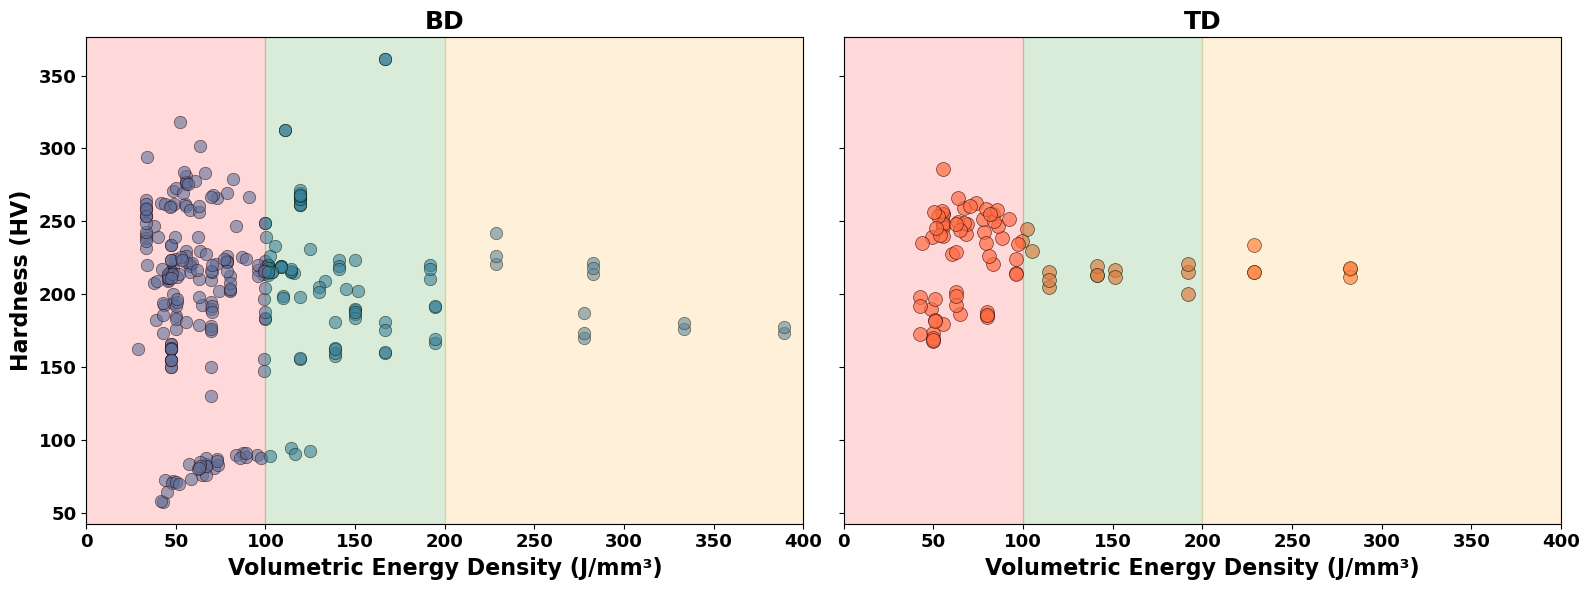


HARDNESS BY VED ZONE

Zone 1: Low Energy (0-100 J/mm³):
  Samples: 199
  Avg hardness: 196.9 HV
  Range: 57.9 - 317.9 HV

Zone 2: Intermediate Energy (100-200 J/mm³):
  Samples: 87
  Avg hardness: 213.8 HV
  Range: 88.9 - 361.1 HV

Zone 3: High Energy (200-400 J/mm³):
  Samples: 13
  Avg hardness: 198.5 HV
  Range: 170.3 - 241.8 HV


In [43]:
# VED vs Hardness analysis

bd = dataset[['Material', 'Volumetric energy density (J/mm3)', 'BD Hardness (HV)']].dropna()
bd = bd[bd['Material'].str.contains('316L', na=False, case=False)]
bd.columns = ['Material', 'VED', 'Hardness']

td = dataset[['Material', 'Volumetric energy density (J/mm3)', 'TD Hardness (HV)']].dropna()
td = td[td['Material'].str.contains('316L', na=False, case=False)]
td.columns = ['Material', 'VED', 'Hardness']

print(f"BD: {len(bd)} | TD: {len(td)} data points")

# Define zone boundaries
ZONE1_END = 100   # Below this = incomplete melting
ZONE2_END = 200  # Below this = stable hardness trend


# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ========== BD ==========
ax1.scatter(bd['VED'], bd['Hardness'], color='steelblue', 
           s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Three zones
ax1.axvspan(0, ZONE1_END, alpha=0.15, color='red')
ax1.axvspan(ZONE1_END, ZONE2_END, alpha=0.15, color='green')
ax1.axvspan(ZONE2_END, 400, alpha=0.15, color='orange')

ax1.set_xlabel('Volumetric Energy Density (J/mm³)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Hardness (HV)', fontsize=16, fontweight='bold')
ax1.set_title('BD', fontsize=18, fontweight='bold')
ax1.tick_params(labelsize=13)
ax1.set_xlim([0, 400])

# ========== TD ==========
ax2.scatter(td['VED'], td['Hardness'], color='coral', 
           s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

# Three zones
ax2.axvspan(0, ZONE1_END, alpha=0.15, color='red')
ax2.axvspan(ZONE1_END, ZONE2_END, alpha=0.15, color='green')
ax2.axvspan(ZONE2_END, 400, alpha=0.15, color='orange')

ax2.set_xlabel('Volumetric Energy Density (J/mm³)', fontsize=16, fontweight='bold')
ax2.set_title('TD', fontsize=18, fontweight='bold')
ax2.tick_params(labelsize=13)
ax2.set_xlim([0, 400])

plt.tight_layout()
plt.savefig('ved_hardness_bd_td.png', dpi=300, bbox_inches='tight')
plt.show()

# Print zone statistics
print("\n" + "="*60)
print("HARDNESS BY VED ZONE")
print("="*60)
for zone_name, ved_min, ved_max in [
    ("Zone 1: Low Energy", 0, ZONE1_END),
    ("Zone 2: Intermediate Energy", ZONE1_END, ZONE2_END),
    ("Zone 3: High Energy", ZONE2_END, 400)
]:
    zone_data = bd[(bd['VED'] >= ved_min) & (bd['VED'] < ved_max)]
    if len(zone_data) > 0:
        print(f"\n{zone_name} ({ved_min}-{ved_max} J/mm³):")
        print(f"  Samples: {len(zone_data)}")
        print(f"  Avg hardness: {zone_data['Hardness'].mean():.1f} HV")
        print(f"  Range: {zone_data['Hardness'].min():.1f} - {zone_data['Hardness'].max():.1f} HV")

BD: 329 | TD: 73 data points


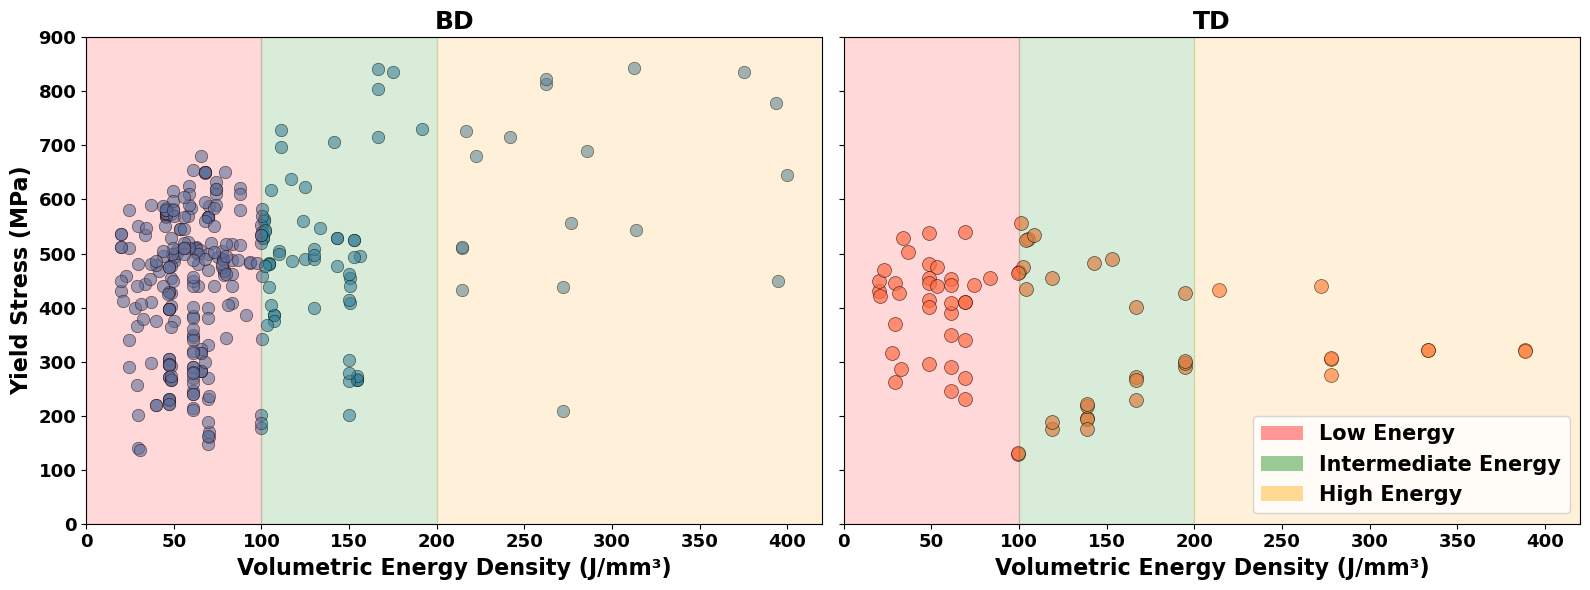


YIELD STRESS BY VED ZONE

Zone 1: Low Energy (0-100 J/mm³):
  Samples: 233
  Avg yield stress: 441.3 MPa
  Range: 137.2 - 680.0 MPa

Zone 2: Intermediate Energy (100-200 J/mm³):
  Samples: 66
  Avg yield stress: 499.3 MPa
  Range: 200.3 - 840.8 MPa

Zone 3: High Energy (200-420 J/mm³):
  Samples: 18
  Avg yield stress: 622.4 MPa
  Range: 208.8 - 843.8 MPa


In [41]:
# VED vs Yield Stress analysis

bd = dataset[['Material', 'Volumetric energy density (J/mm3)', 'BD Yield Stress (MPa)']].dropna()
bd = bd[bd['Material'].str.contains('316L', na=False, case=False)]
bd.columns = ['Material', 'VED', 'Yield Stress']

td = dataset[['Material', 'Volumetric energy density (J/mm3)', 'TD Yield Stress (MPa)']].dropna()
td = td[td['Material'].str.contains('316L', na=False, case=False)]
td.columns = ['Material', 'VED', 'Yield Stress']

print(f"BD: {len(bd)} | TD: {len(td)} data points")

# Define zone boundaries
ZONE1_END = 100   # Below this = incomplete melting
ZONE2_END = 200  # Below this = stable yield stress trend


# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ========== BD ==========
ax1.scatter(bd['VED'], bd['Yield Stress'], color='steelblue', 
           s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Three zones
ax1.axvspan(0, ZONE1_END, alpha=0.15, color='red')
ax1.axvspan(ZONE1_END, ZONE2_END, alpha=0.15, color='green')
ax1.axvspan(ZONE2_END, 420, alpha=0.15, color='orange')

ax1.set_xlabel('Volumetric Energy Density (J/mm³)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Yield Stress (MPa)', fontsize=16, fontweight='bold')
ax1.set_title('BD', fontsize=18, fontweight='bold')
ax1.tick_params(labelsize=13)
ax1.set_xlim([0, 420])
ax1.set_ylim([0, 900])

# ========== TD ==========
ax2.scatter(td['VED'], td['Yield Stress'], color='coral', 
           s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

# Three zones
ax2.axvspan(0, ZONE1_END, alpha=0.15, color='red')
ax2.axvspan(ZONE1_END, ZONE2_END, alpha=0.15, color='green')
ax2.axvspan(ZONE2_END, 420, alpha=0.15, color='orange')

ax2.set_xlabel('Volumetric Energy Density (J/mm³)', fontsize=16, fontweight='bold')
ax2.set_title('TD', fontsize=18, fontweight='bold')
ax2.tick_params(labelsize=13)
ax2.set_xlim([0, 420])
ax2.set_ylim([0, 900])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.4, label='Low Energy'),
    Patch(facecolor='green', alpha=0.4, label='Intermediate Energy'),
    Patch(facecolor='orange', alpha=0.4, label='High Energy'),
]
ax2.legend(handles=legend_elements, fontsize=15, loc='lower right')

plt.tight_layout()
plt.savefig('ved_yield_stress_bd_td.png', dpi=300, bbox_inches='tight')
plt.show()

# Print zone statistics
print("\n" + "="*60)
print("YIELD STRESS BY VED ZONE")
print("="*60)
for zone_name, ved_min, ved_max in [
    ("Zone 1: Low Energy", 0, ZONE1_END),
    ("Zone 2: Intermediate Energy", ZONE1_END, ZONE2_END),
    ("Zone 3: High Energy", ZONE2_END, 420)
]:
    zone_data = bd[(bd['VED'] >= ved_min) & (bd['VED'] < ved_max)]
    if len(zone_data) > 0:
        print(f"\n{zone_name} ({ved_min}-{ved_max} J/mm³):")
        print(f"  Samples: {len(zone_data)}")
        print(f"  Avg yield stress: {zone_data['Yield Stress'].mean():.1f} MPa")
        print(f"  Range: {zone_data['Yield Stress'].min():.1f} - {zone_data['Yield Stress'].max():.1f} MPa")

In [32]:
from sklearn.metrics import r2_score

In [33]:
# Prepare BD and TD data
bd_data = dataset[['BD Hardness (HV)', 'BD Yield Stress (MPa)', 'Volumetric energy density (J/mm3)']].dropna()
td_data = dataset[['TD Hardness (HV)', 'TD Yield Stress (MPa)', 'Volumetric energy density (J/mm3)']].dropna()

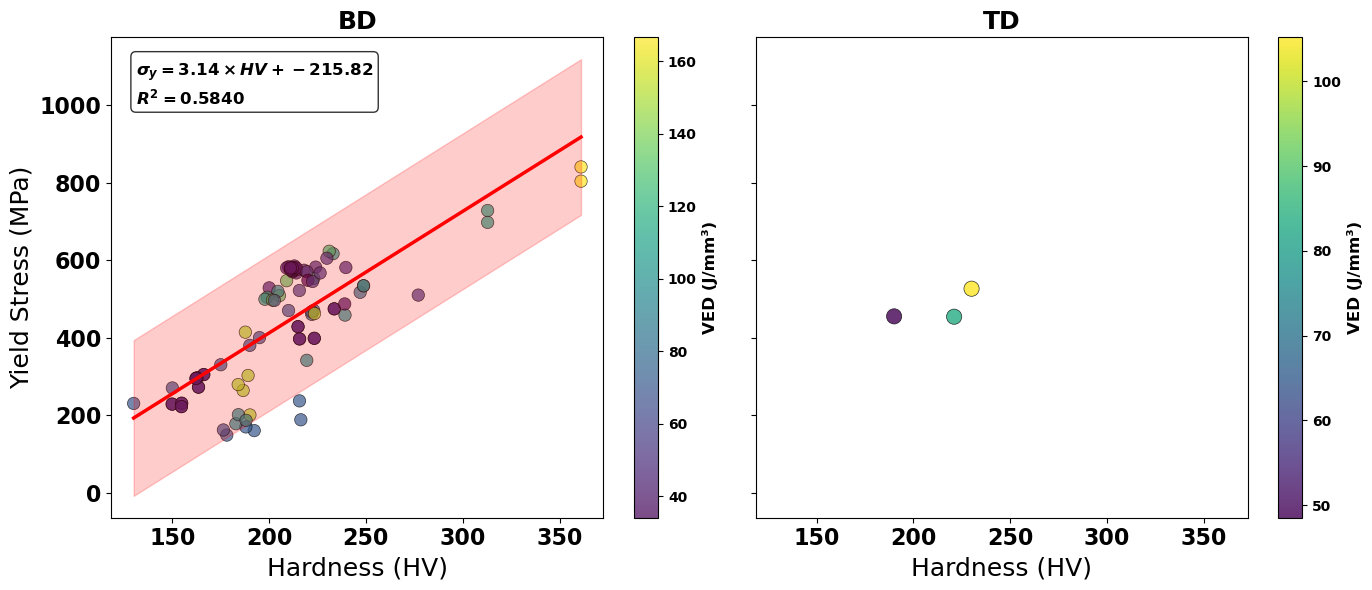

BD Linear Fit: σy = 3.14×HV + -215.82
BD R² = 0.5840


In [34]:
# YS vs Hardness - Linear Fit with VED coloring

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ========== BD PLOT ==========
x_bd = bd_data['BD Hardness (HV)'].values
y_bd = bd_data['BD Yield Stress (MPa)'].values
ved_bd = bd_data['Volumetric energy density (J/mm3)'].values

# Scatter plot colored by VED
scatter_bd = axes[0].scatter(x_bd, y_bd, c=ved_bd, cmap='viridis', 
                             s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

# Linear fit
coeffs_bd = np.polyfit(x_bd, y_bd, 1)
y_pred_bd = np.polyval(coeffs_bd, x_bd)
r2_bd = r2_score(y_bd, y_pred_bd)

# Plot fit line with confidence interval
x_fit = np.linspace(x_bd.min(), x_bd.max(), 300)
y_fit = np.polyval(coeffs_bd, x_fit)
axes[0].plot(x_fit, y_fit, 'r-', linewidth=2.5, zorder=5)

# Add shaded confidence interval (95%)
residuals = y_bd - y_pred_bd
std_error = np.std(residuals)
ci = 1.96 * std_error  # 95% CI
axes[0].fill_between(x_fit, y_fit - ci, y_fit + ci, alpha=0.2, color='red')

# Add equation and R² on plot
eq_text = f'$\\sigma_y = {coeffs_bd[0]:.2f} \\times HV + {coeffs_bd[1]:.2f}$\n$R^2 = {r2_bd:.4f}$'
axes[0].text(0.05, 0.95, eq_text, transform=axes[0].transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_title('BD', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Hardness (HV)', fontsize=18)
axes[0].set_ylabel('Yield Stress (MPa)', fontsize=18)
axes[0].tick_params(labelsize=16)

# Add colorbar for BD
cbar_bd = plt.colorbar(scatter_bd, ax=axes[0])
cbar_bd.set_label('VED (J/mm³)', fontsize=12, fontweight='bold')

# ========== TD PLOT ==========
x_td = td_data['TD Hardness (HV)'].values
y_td = td_data['TD Yield Stress (MPa)'].values
ved_td = td_data['Volumetric energy density (J/mm3)'].values

# Scatter plot colored by VED
scatter_td = axes[1].scatter(x_td, y_td, c=ved_td, cmap='viridis', 
                            s=120, alpha=0.8, edgecolors='black', linewidth=0.5)

axes[1].set_title('TD', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Hardness (HV)', fontsize=18)
axes[1].tick_params(labelsize=16)

# Add colorbar for TD
cbar_td = plt.colorbar(scatter_td, ax=axes[1])
cbar_td.set_label('VED (J/mm³)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ys_hardness_linear_ved.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"BD Linear Fit: σy = {coeffs_bd[0]:.2f}×HV + {coeffs_bd[1]:.2f}")
print(f"BD R² = {r2_bd:.4f}")

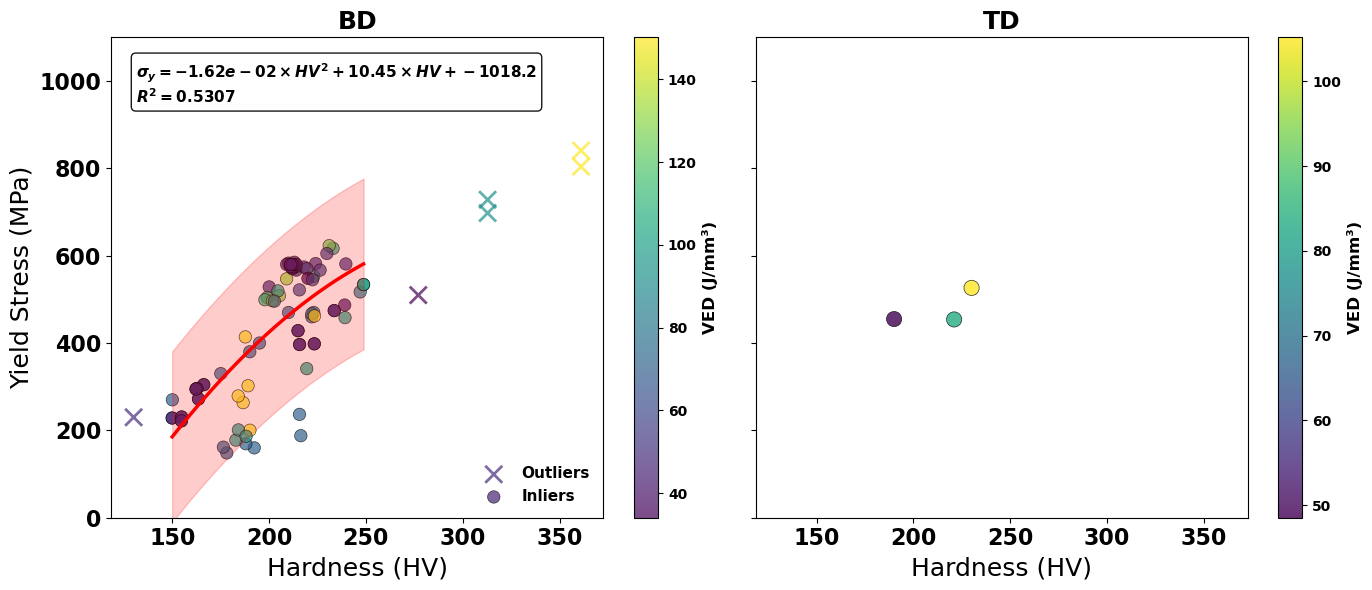

BD: σy = -1.62e-02×HV² + 10.45×HV + -1018.2
BD R² = 0.5307


In [35]:
# YS vs Hardness - Polynomial Fit with VED coloring and Outlier Removal

# IQR filter for outliers
def iqr_filter(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x >= q1 - k*iqr) & (x <= q3 + k*iqr)

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ========== BD ==========
x_bd = bd_data['BD Hardness (HV)'].values
y_bd = bd_data['BD Yield Stress (MPa)'].values
ved_bd = bd_data['Volumetric energy density (J/mm3)'].values

# Identify outliers
mask_bd = iqr_filter(x_bd) & iqr_filter(y_bd)
x_in, y_in, ved_in = x_bd[mask_bd], y_bd[mask_bd], ved_bd[mask_bd]
x_out, y_out, ved_out = x_bd[~mask_bd], y_bd[~mask_bd], ved_bd[~mask_bd]

# Plot outliers (different marker)
if len(x_out) > 0:
    ax1.scatter(x_out, y_out, c=ved_out, cmap='viridis', marker='x', 
               s=150, alpha=0.7, linewidths=2, label='Outliers')

# Plot inliers
scatter1 = ax1.scatter(x_in, y_in, c=ved_in, cmap='viridis', marker='o',
                      s=80, alpha=0.7, edgecolors='black', linewidth=0.5, label='Inliers')

# Polynomial fit (on inliers only)
z_bd = np.polyfit(x_in, y_in, 2)
y_pred = np.polyval(z_bd, x_in)
r2_bd = r2_score(y_in, y_pred)

# Plot fit
x_fit = np.linspace(x_in.min(), x_in.max(), 300)
y_fit = np.polyval(z_bd, x_fit)
ax1.plot(x_fit, y_fit, 'r-', linewidth=2.5)

# Confidence interval
residuals = y_in - y_pred
std_err = np.std(residuals)
ci = 1.96 * std_err
ax1.fill_between(x_fit, y_fit - ci, y_fit + ci, alpha=0.2, color='red')

# Equation and R²
a, b, c = z_bd
eq_text = f'$\\sigma_y = {a:.2e} \\times HV^2 + {b:.2f} \\times HV + {c:.1f}$\n$R^2 = {r2_bd:.4f}$'
ax1.text(0.05, 0.95, eq_text, transform=ax1.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax1.set_xlabel('Hardness (HV)', fontsize=18)
ax1.set_ylabel('Yield Stress (MPa)', fontsize=18)
ax1.set_title('BD', fontsize=18, fontweight='bold')
ax1.tick_params(labelsize=16)
ax1.set_ylim([0, 1100])  
ax1.legend(fontsize=11, loc='lower right', frameon=False)

# Colorbar
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('VED (J/mm³)', fontsize=12, fontweight='bold')

# ========== TD ==========
x_td = td_data['TD Hardness (HV)'].values
y_td = td_data['TD Yield Stress (MPa)'].values
ved_td = td_data['Volumetric energy density (J/mm3)'].values

# Plot all TD points (no filtering due to fewer points)
scatter2 = ax2.scatter(x_td, y_td, c=ved_td, cmap='viridis', marker='o',
                      s=120, alpha=0.8, edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Hardness (HV)', fontsize=18)
ax2.set_title('TD', fontsize=18, fontweight='bold')
ax2.tick_params(labelsize=16)
ax2.set_ylim([0, 1100])

# Colorbar
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('VED (J/mm³)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ys_hardness_polynomial_ved.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"BD: σy = {a:.2e}×HV² + {b:.2f}×HV + {c:.1f}")
print(f"BD R² = {r2_bd:.4f}")

Meander: R² = 0.373
Stripe: R² = 0.701


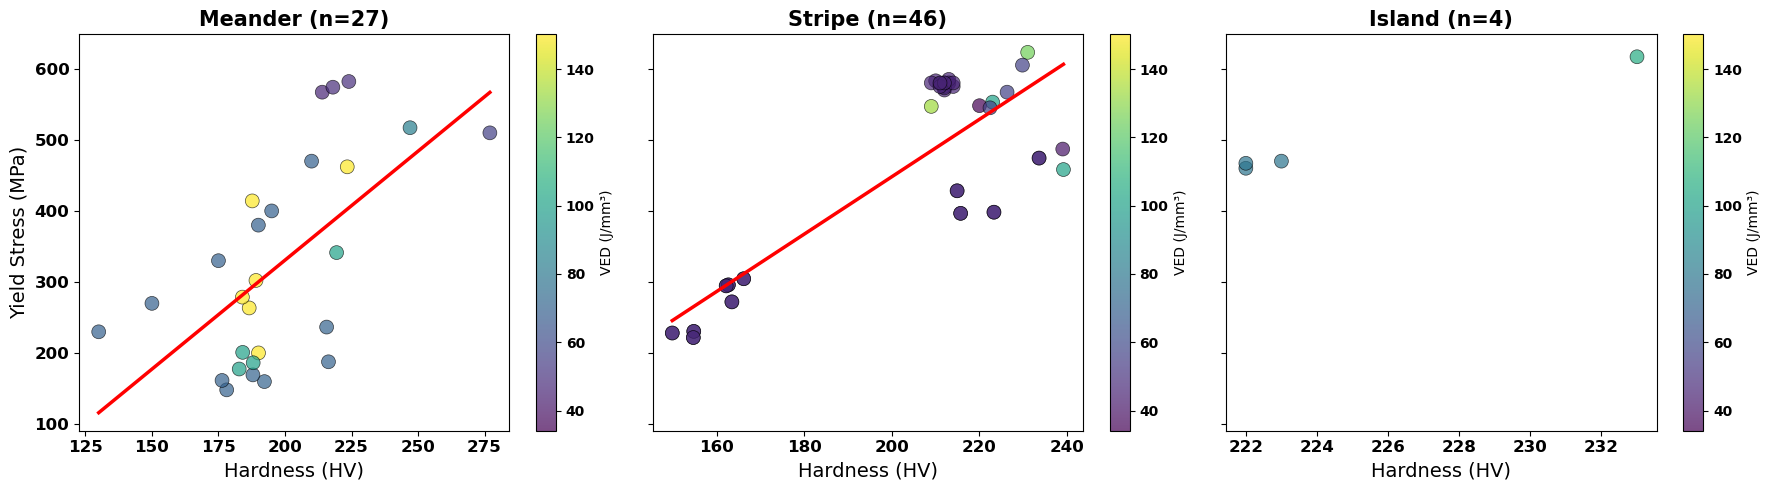

In [36]:
# YS vs Hardness by Scanning Strategy - Linear Fit with VED coloring

# Add scanning strategy and filter for 316L
data = bd_data.copy()
data['Material'] = dataset.loc[data.index, 'Material']
data['Strategy'] = dataset.loc[data.index, 'Scanning strategy']
data = data[data['Material'].str.contains('316L', na=False, case=False)]
data = data.dropna(subset=['Strategy'])

# Global VED range
ved_min, ved_max = data['Volumetric energy density (J/mm3)'].min(), data['Volumetric energy density (J/mm3)'].max()

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, strategy in enumerate(['Meander', 'Stripe', 'Island']):
    subset = data[data['Strategy'].str.contains(strategy, case=False, na=False)]
    
    # Scatter
    scatter = axes[idx].scatter(subset['BD Hardness (HV)'], subset['BD Yield Stress (MPa)'],
                               c=subset['Volumetric energy density (J/mm3)'],
                               cmap='viridis', vmin=ved_min, vmax=ved_max,
                               s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Linear fit
    if len(subset) >= 5:
        z = np.polyfit(subset['BD Hardness (HV)'], subset['BD Yield Stress (MPa)'], 1)
        x_fit = np.linspace(subset['BD Hardness (HV)'].min(), subset['BD Hardness (HV)'].max(), 100)
        axes[idx].plot(x_fit, np.poly1d(z)(x_fit), 'r-', linewidth=2.5)
        
        r2 = r2_score(subset['BD Yield Stress (MPa)'], np.poly1d(z)(subset['BD Hardness (HV)']))
        print(f"{strategy}: R² = {r2:.3f}")
    
    axes[idx].set_title(f'{strategy} (n={len(subset)})', fontsize=15, fontweight='bold')
    axes[idx].set_xlabel('Hardness (HV)', fontsize=14)
    axes[idx].tick_params(labelsize=12)
    plt.colorbar(scatter, ax=axes[idx], label='VED (J/mm³)')

axes[0].set_ylabel('Yield Stress (MPa)', fontsize=14)
plt.tight_layout()
plt.savefig('ys_hardness_by_strategy.png', dpi=300, bbox_inches='tight')
plt.show()

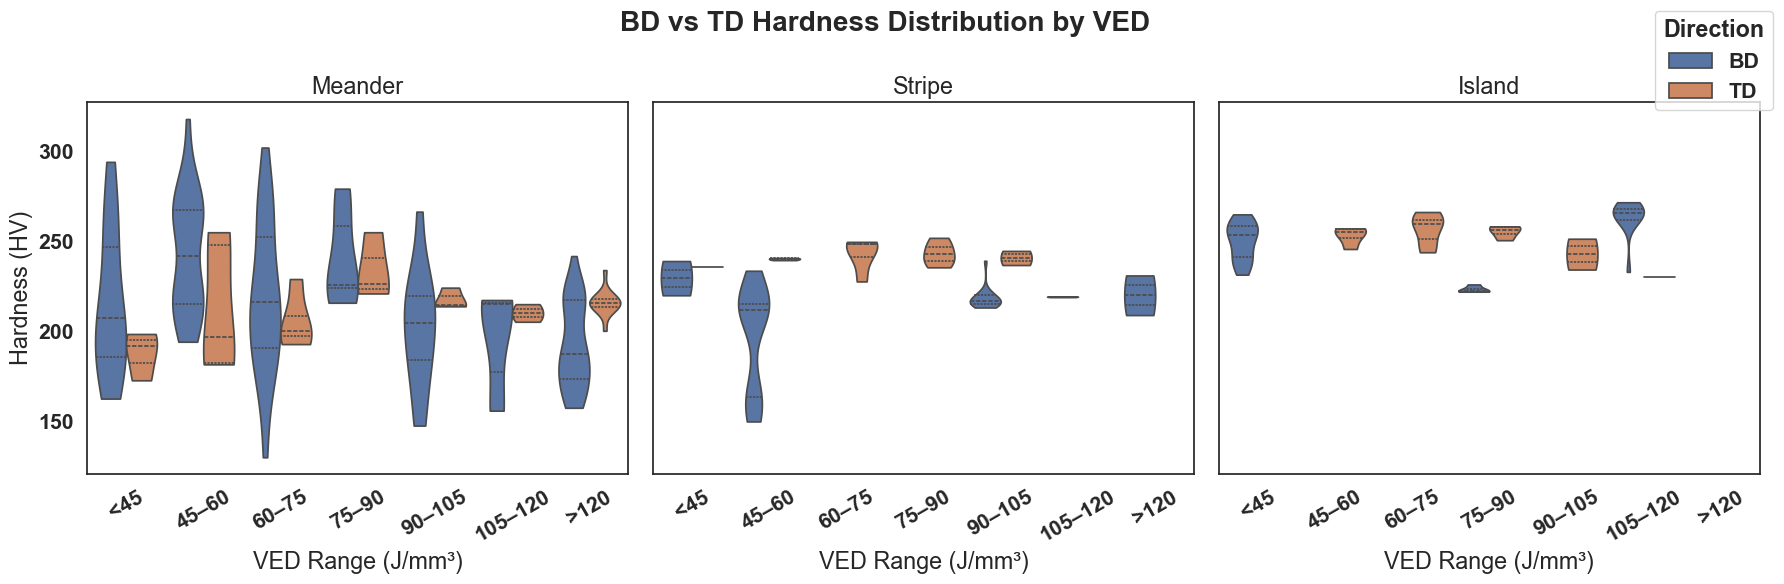

In [37]:
# VED vs Hardness violins split by scanning strategy

ved_col = 'Volumetric energy density (J/mm3)'
scan_col = 'Scanning strategy' 

bins = [0, 45, 60, 75, 90, 105, 120, np.inf]
labels = ['<45','45–60','60–75','75–90','90–105','105–120','>120']

dataset[ved_col] = pd.to_numeric(dataset[ved_col], errors='coerce')
dataset['VED Bin'] = pd.cut(dataset[ved_col], bins=bins, labels=labels, include_lowest=True)

df_long = dataset.melt(
    id_vars=['VED Bin', scan_col],
    value_vars=['BD Hardness (HV)', 'TD Hardness (HV)'],
    var_name='Direction', value_name='Hardness (HV)'
).dropna(subset=['VED Bin', scan_col, 'Hardness (HV)'])

df_long['Direction'] = df_long['Direction'].str.replace(' Hardness (HV)', '', regex=False)

strategies = ['Meander', 'Stripe', 'Island']
sns.set_theme(style="white", context="notebook", font_scale=1.4)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, s in zip(axes, strategies):
    sns.violinplot(
        data=df_long[df_long[scan_col] == s],
        x='VED Bin', y='Hardness (HV)', hue='Direction',
        inner='quartile', cut=0, density_norm='width', dodge=True, ax=ax
    )
    ax.set_title(s)
    ax.set_xlabel('VED Range (J/mm³)')
    ax.tick_params(axis='x', rotation=30)
    ax.get_legend().remove()

axes[0].set_ylabel('Hardness (HV)')
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, title='Direction', loc='upper right')
fig.suptitle('BD vs TD Hardness Distribution by VED', fontweight='bold')

plt.tight_layout()
plt.show()


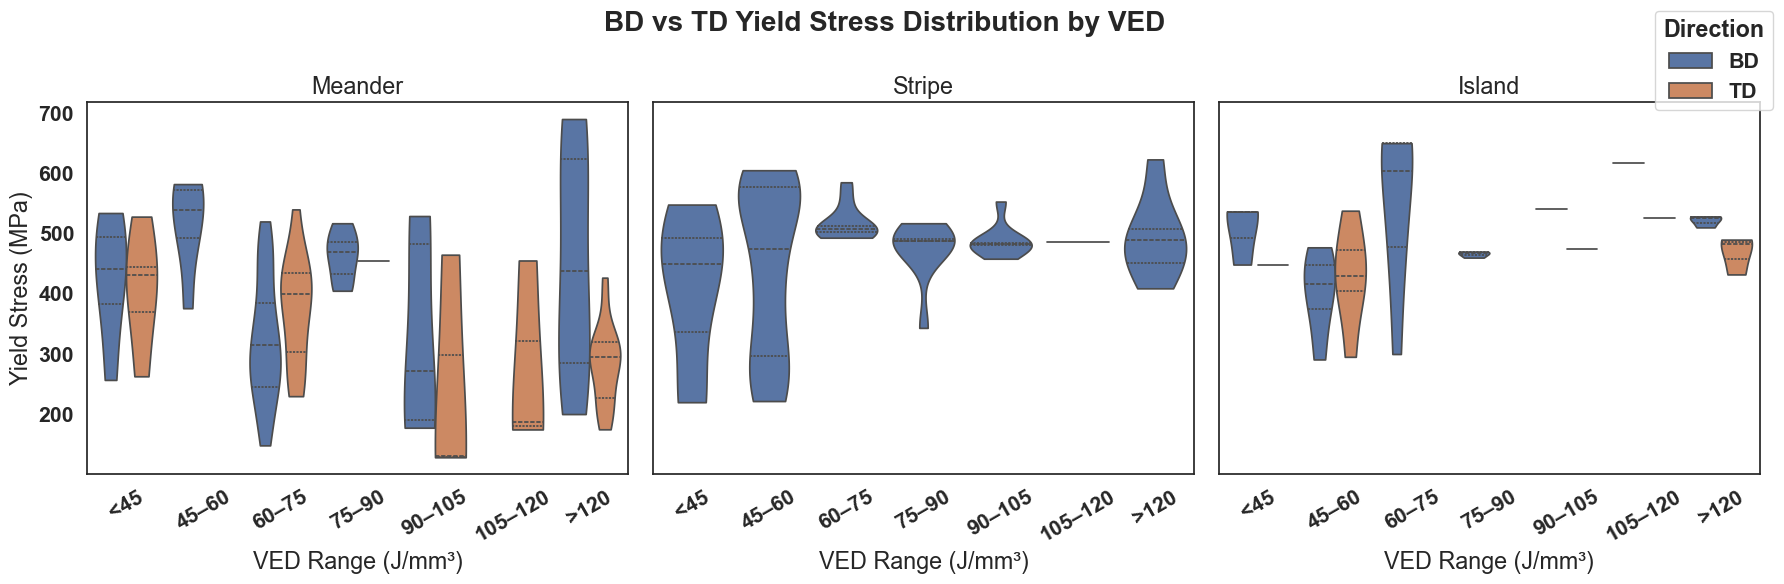

In [38]:
# VED vs Yield Stress violins split by scanning strategy

ved_col = 'Volumetric energy density (J/mm3)'
scan_col = 'Scanning strategy' 

bins = [0, 45, 60, 75, 90, 105, 120, np.inf]
labels = ['<45','45–60','60–75','75–90','90–105','105–120','>120']

dataset[ved_col] = pd.to_numeric(dataset[ved_col], errors='coerce')
dataset['VED Bin'] = pd.cut(dataset[ved_col], bins=bins, labels=labels, include_lowest=True)

df_long = dataset.melt(
    id_vars=['VED Bin', scan_col],
    value_vars=['BD Yield Stress (MPa)', 'TD Yield Stress (MPa)'],
    var_name='Direction', value_name='Yield Stress (MPa)'
).dropna(subset=['VED Bin', scan_col, 'Yield Stress (MPa)'])

df_long['Direction'] = df_long['Direction'].str.replace(' Yield Stress (MPa)', '', regex=False)

strategies = ['Meander', 'Stripe', 'Island']
sns.set_theme(style="white", context="notebook", font_scale=1.4)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, s in zip(axes, strategies):
    sns.violinplot(
        data=df_long[df_long[scan_col] == s],
        x='VED Bin', y='Yield Stress (MPa)', hue='Direction',
        inner='quartile', cut=0, density_norm='width', dodge=True, ax=ax
    )
    ax.set_title(s)
    ax.set_xlabel('VED Range (J/mm³)')
    ax.tick_params(axis='x', rotation=30)
    ax.get_legend().remove()

axes[0].set_ylabel('Yield Stress (MPa)')
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, title='Direction', loc='upper right')
fig.suptitle('BD vs TD Yield Stress Distribution by VED', fontweight='bold')

plt.tight_layout()
plt.show()


# Correlation Heatmaps

In [39]:
import seaborn as sns

In [40]:
# Set the input parameters we want for to analyse for the correlation
input_params = ['Laser Power (W)', 'Scanning Speed (mm/s)', 'Layer Thickness (um)', 'Hatch Spacing (um)', 'Volumetric energy density (J/mm3)']
output_params = ['BD Yield Stress (MPa)', 'TD Yield Stress (MPa)','BD Hardness (HV)', 'TD Hardness (HV)', 'BD Ultimate Tensile Stress (MPa)', 'TD Ultimate Tensile Stress (MPa)', 'BD Elongation (%)', 'TD Elongation (%)', 'Consolidation (%)']

# Import excel data
dataset = pd.read_excel(path)

# Split data into processing parameters and properties (input and output)
x_df = dataset[input_params]
y_df = dataset[output_params]

In [12]:
x_df

NameError: name 'x_df' is not defined

In [42]:
y_df

,BD Yield Stress (MPa),TD Yield Stress (MPa),BD Hardness (HV),TD Hardness (HV),BD Ultimate Tensile Stress (MPa),TD Ultimate Tensile Stress (MPa),BD Elongation (%),TD Elongation (%),Consolidation (%)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.828000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.524000
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.388000
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.887000
4,487.0,NaN,NaN,NaN,594.0,NaN,49.0,NaN,99.800000
...,...,...,...,...,...,...,...,...,...
918,NaN,NaN,271.658538,NaN,NaN,NaN,NaN,NaN,96.601308
919,NaN,NaN,261.512195,NaN,NaN,NaN,NaN,NaN,84.248368
920,NaN,NaN,265.609756,NaN,NaN,NaN,NaN,NaN,85.686276
921,NaN,NaN,267.463413,NaN,NaN,NaN,NaN,NaN,87.908497


In [43]:
all_df = pd.concat([x_df, y_df], axis=1)
# all_df = all_df.corr('spearman')
# all_df = all_df.drop(index=input_params)
# all_df = all_df.drop(output_params, axis=1)
all_df

,Laser Power (W),Scanning Speed (mm/s),Layer Thickness (um),Hatch Spacing (um),Volumetric energy density (J/mm3),BD Yield Stress (MPa),TD Yield Stress (MPa),BD Hardness (HV),TD Hardness (HV),BD Ultimate Tensile Stress (MPa),TD Ultimate Tensile Stress (MPa),BD Elongation (%),TD Elongation (%),Consolidation (%)
0,90.0,1500.0,25.0,56.0,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.828000
1,90.0,600.0,25.0,84.0,71.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.524000
2,90.0,300.0,45.0,84.0,79.365079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.388000
3,90.0,300.0,25.0,84.0,142.857143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.887000
4,200.0,1000.0,50.0,80.0,50.000000,487.0,NaN,NaN,NaN,594.0,NaN,49.0,NaN,99.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,80.0,343.0,35.0,56.0,119.000000,NaN,NaN,271.658538,NaN,NaN,NaN,NaN,NaN,96.601308
919,90.0,386.0,35.0,56.0,119.000000,NaN,NaN,261.512195,NaN,NaN,NaN,NaN,NaN,84.248368
920,30.0,100.0,45.0,56.0,119.000000,NaN,NaN,265.609756,NaN,NaN,NaN,NaN,NaN,85.686276
921,50.0,167.0,45.0,56.0,119.000000,NaN,NaN,267.463413,NaN,NaN,NaN,NaN,NaN,87.908497


In [44]:
all_df

,Laser Power (W),Scanning Speed (mm/s),Layer Thickness (um),Hatch Spacing (um),Volumetric energy density (J/mm3),BD Yield Stress (MPa),TD Yield Stress (MPa),BD Hardness (HV),TD Hardness (HV),BD Ultimate Tensile Stress (MPa),TD Ultimate Tensile Stress (MPa),BD Elongation (%),TD Elongation (%),Consolidation (%)
0,90.0,1500.0,25.0,56.0,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.828000
1,90.0,600.0,25.0,84.0,71.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.524000
2,90.0,300.0,45.0,84.0,79.365079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.388000
3,90.0,300.0,25.0,84.0,142.857143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.887000
4,200.0,1000.0,50.0,80.0,50.000000,487.0,NaN,NaN,NaN,594.0,NaN,49.0,NaN,99.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,80.0,343.0,35.0,56.0,119.000000,NaN,NaN,271.658538,NaN,NaN,NaN,NaN,NaN,96.601308
919,90.0,386.0,35.0,56.0,119.000000,NaN,NaN,261.512195,NaN,NaN,NaN,NaN,NaN,84.248368
920,30.0,100.0,45.0,56.0,119.000000,NaN,NaN,265.609756,NaN,NaN,NaN,NaN,NaN,85.686276
921,50.0,167.0,45.0,56.0,119.000000,NaN,NaN,267.463413,NaN,NaN,NaN,NaN,NaN,87.908497


In [45]:
tmp = pd.concat([x_df, y_df], axis=1)
tmp = tmp.dropna()
tmp = tmp.corr('spearman')
tmp

,Laser Power (W),Scanning Speed (mm/s),Layer Thickness (um),Hatch Spacing (um),Volumetric energy density (J/mm3),BD Yield Stress (MPa),TD Yield Stress (MPa),BD Hardness (HV),TD Hardness (HV),BD Ultimate Tensile Stress (MPa),TD Ultimate Tensile Stress (MPa),BD Elongation (%),TD Elongation (%),Consolidation (%)
Laser Power (W),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scanning Speed (mm/s),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Layer Thickness (um),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hatch Spacing (um),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volumetric energy density (J/mm3),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BD Yield Stress (MPa),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TD Yield Stress (MPa),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BD Hardness (HV),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TD Hardness (HV),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BD Ultimate Tensile Stress (MPa),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0, 0.5, 'BD Yield Stress (MPa)'),
  Text(0, 1.5, 'TD Yield Stress (MPa)'),
  Text(0, 2.5, 'BD Hardness (HV)'),
  Text(0, 3.5, 'TD Hardness (HV)'),
  Text(0, 4.5, 'BD Ultimate Tensile Stress (MPa)'),
  Text(0, 5.5, 'TD Ultimate Tensile Stress (MPa)'),
  Text(0, 6.5, 'BD Elongation (%)'),
  Text(0, 7.5, 'TD Elongation (%)'),
  Text(0, 8.5, 'Consolidation (%)')])

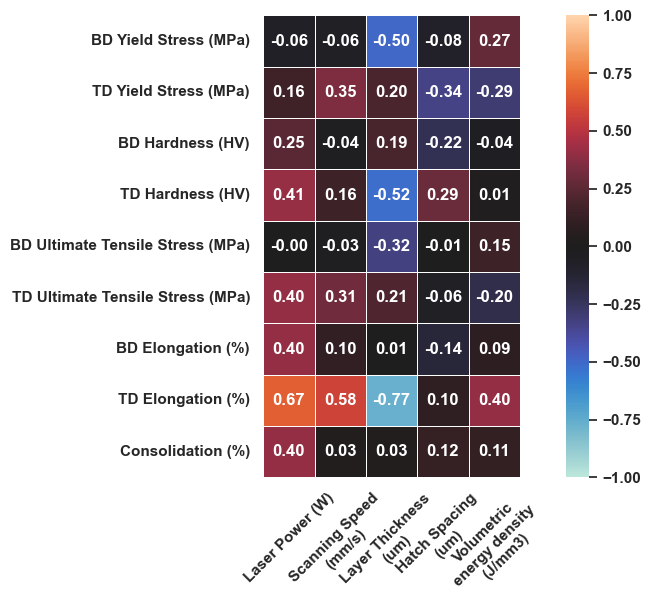

In [46]:
# Spearman's Correlation Coefficient
# Spearman shows monotonic relationships
all_df = pd.concat([x_df, y_df], axis=1)
all_df = all_df.corr('spearman')
all_df = all_df.drop(index=input_params)
all_df = all_df.drop(output_params, axis=1)

sns.set_theme(font_scale=1)
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(all_df, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f')
labels_x = ['\n'.join(wrap(l, 15)) for l in input_params] 
heatmap.set_xticklabels(labels_x);
plt.xticks(rotation=45)
plt.yticks(rotation=0)

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0, 0.5, 'BD Yield Stress (MPa)'),
  Text(0, 1.5, 'TD Yield Stress (MPa)'),
  Text(0, 2.5, 'BD Hardness (HV)'),
  Text(0, 3.5, 'TD Hardness (HV)'),
  Text(0, 4.5, 'BD Ultimate Tensile Stress (MPa)'),
  Text(0, 5.5, 'TD Ultimate Tensile Stress (MPa)'),
  Text(0, 6.5, 'BD Elongation (%)'),
  Text(0, 7.5, 'TD Elongation (%)'),
  Text(0, 8.5, 'Consolidation (%)')])

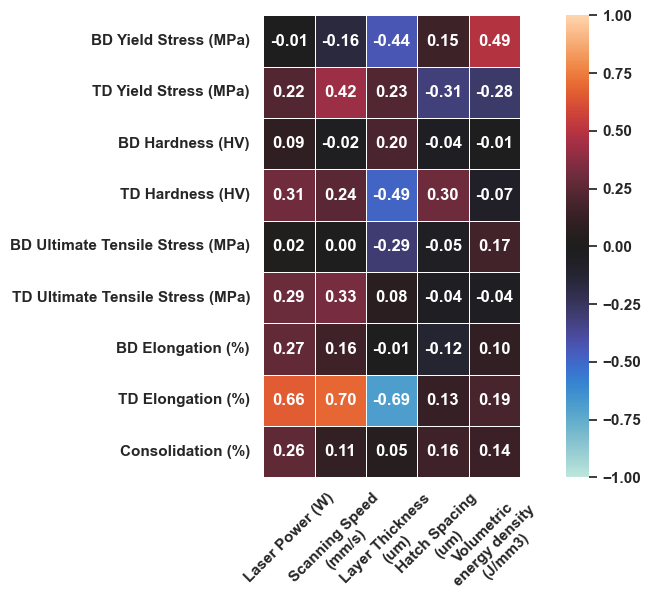

In [47]:
# Pearson's Correlation Coefficient
all_df = pd.concat([x_df, y_df], axis=1)
all_df = all_df.corr('pearson')
all_df = all_df.drop(index=input_params)
all_df = all_df.drop(output_params, axis=1)

sns.set_theme(font_scale=1)
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(all_df, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f')
labels_x = [ '\n'.join(wrap(l, 15)) for l in input_params]
heatmap.set_xticklabels(labels_x);
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Variation Inflation Factor

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [21]:
# Define variables
input_var = ['Laser Power (W)',
             'Scanning Speed (mm/s)',
             'Layer Thickness (um)',
             'Hatch Spacing (um)',
             'Volumetric energy density (J/mm3)',
             'Scanning strategy']

output_var = ['BD Hardness (HV)',
              'TD Hardness (HV)',
              'BD Yield Stress (MPa)',
              'TD Yield Stress (MPa)']

print(f"Dataset loaded: {dataset.shape}")

Dataset loaded: (923, 79)


            Variables      VIF
 Layer Thickness (um) 6.503294
   Hatch Spacing (um) 5.034662
      Laser Power (W) 4.080803
Scanning Speed (mm/s) 3.525317


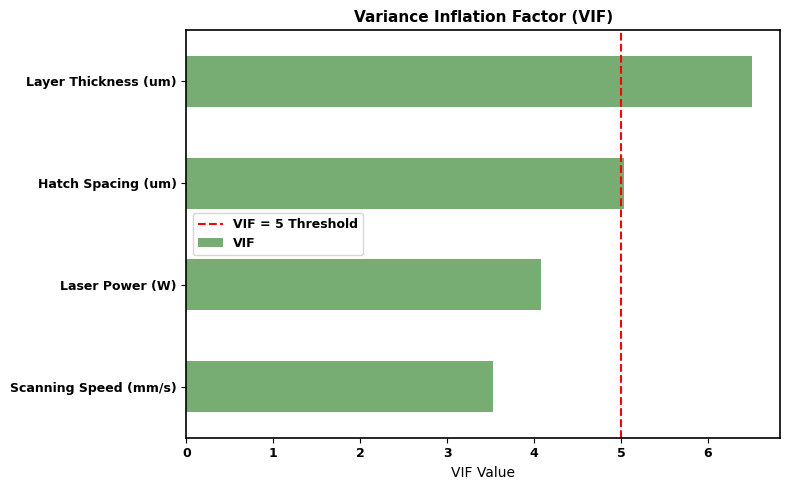

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Prepare VIF dataframe (exclude derived variable)
vif_df = x_df.copy()
if 'Volumetric energy density (J/mm3)' in vif_df.columns:
    vif_df = vif_df.drop(['Volumetric energy density (J/mm3)'], axis=1)

vif_df = vif_df.select_dtypes(include=[np.number])
vif_df = vif_df.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF
vif = pd.DataFrame()
vif["Variables"] = vif_df.columns
vif["VIF"] = [variance_inflation_factor(vif_df.values, i) 
               for i in range(vif_df.shape[1])]

vif = vif.sort_values('VIF', ascending=False)
print(vif.to_string(index=False))

ax = vif.sort_values('VIF').plot.barh(x='Variables', y='VIF', legend=False, figsize=(8, 5), color="#77AC72") # '#4c72b0'
ax.axvline(5, color='red', linestyle='--', label='VIF = 5 Threshold')
ax.set_title('Variance Inflation Factor (VIF)', fontsize=11, fontweight='bold')
ax.set_xlabel('VIF Value', fontsize=10)
ax.set_ylabel('')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9)

ax.set_facecolor('white')
ax.figure.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

# One-Hot Encoding

In [23]:
# Standardize scanning strategy
dataset['Scanning strategy'] = dataset['Scanning strategy'].str.title()

# Create dataframes
x_df = dataset[input_var].copy()
y_df = dataset[output_var].copy()

# One-hot encoding
strategy_dummies = pd.get_dummies(x_df['Scanning strategy'], prefix='Strategy', drop_first=False)
x_df = pd.concat([x_df, strategy_dummies], axis=1)
x_df = x_df.drop('Scanning strategy', axis=1)

print(f"Features after encoding: {x_df.shape[1]}")
print("\nAll feature names:")
for i, col in enumerate(x_df.columns, 1):
    print(f"  {i}. {col}")

Features after encoding: 8

All feature names:
  1. Laser Power (W)
  2. Scanning Speed (mm/s)
  3. Layer Thickness (um)
  4. Hatch Spacing (um)
  5. Volumetric energy density (J/mm3)
  6. Strategy_Island
  7. Strategy_Meander
  8. Strategy_Stripe


# Random Forest (Input - Hardness)

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [27]:
print(f"Before cleaning:")
print(f"  x_df: {len(x_df)} rows")
print(f"  y_df: {len(y_df)} rows")

# Drop rows with missing INPUT values only
x_df = x_df.dropna()

# Keep outputs aligned (but DON'T drop NAs from outputs!)
y_df = y_df.loc[x_df.index]

print(f"\nAfter cleaning:")
print(f"  x_df: {len(x_df)} rows")
print(f"  y_df: {len(y_df)} rows")

print(f"\nAvailable samples per output:")
print(f"  BD Hardness: {y_df['BD Hardness (HV)'].notna().sum()} samples")
print(f"  TD Hardness: {y_df['TD Hardness (HV)'].notna().sum()} samples")
print(f"  BD Yield Stress: {y_df['BD Yield Stress (MPa)'].notna().sum()} samples")
print(f"  TD Yield Stress: {y_df['TD Yield Stress (MPa)'].notna().sum()} samples")

Before cleaning:
  x_df: 923 rows
  y_df: 923 rows

After cleaning:
  x_df: 810 rows
  y_df: 810 rows

Available samples per output:
  BD Hardness: 297 samples
  TD Hardness: 82 samples
  BD Yield Stress: 327 samples
  TD Yield Stress: 71 samples


BD HARDNESS - RANDOM FOREST WITH HYPERPARAMETER TUNING

Total samples: 297
Training: 237 | Test: 60
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best hyperparameters:
  max_depth: 20
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

RESULTS:
  Train R²:     0.9534
  Test R²:      0.9306
  Test RMSE:    16.09 HV
  Test MAE:     10.76 HV
  Overfitting:  0.0228

Top 5 Most Important Features:
  Hatch Spacing (um)                       31.93%
  Laser Power (W)                          29.78%
  Scanning Speed (mm/s)                    13.00%
  Layer Thickness (um)                     10.99%
  Volumetric energy density (J/mm3)         7.05%


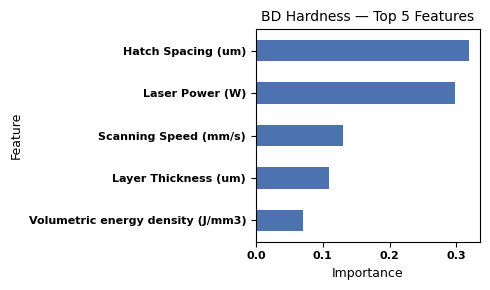

In [30]:
# BD Hardness - Random Forest with Hyperparameter Tuning

print("BD HARDNESS - RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*70)

# Prepare data
y_bd = y_df['BD Hardness (HV)'].dropna()
X_bd = x_df.loc[y_bd.index]

print(f"\nTotal samples: {len(y_bd)}")

# Split data
X_train_bd, X_test_bd, y_train_bd, y_test_bd = train_test_split(X_bd, y_bd, test_size=0.2, random_state=42)

print(f"Training: {len(X_train_bd)} | Test: {len(X_test_bd)}")

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_bd = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

grid_search_bd.fit(X_train_bd, y_train_bd)

print("\nBest hyperparameters:")
for param, value in grid_search_bd.best_params_.items():
    print(f"  {param}: {value}")

# Best model
rf_hardness_bd = grid_search_bd.best_estimator_

# Predictions
y_pred_train_bd = rf_hardness_bd.predict(X_train_bd)
y_pred_test_bd = rf_hardness_bd.predict(X_test_bd)

# Metrics
train_r2_bd = r2_score(y_train_bd, y_pred_train_bd)
test_r2_bd = r2_score(y_test_bd, y_pred_test_bd)
test_rmse_bd = np.sqrt(mean_squared_error(y_test_bd, y_pred_test_bd))
test_mae_bd = mean_absolute_error(y_test_bd, y_pred_test_bd)

print(f"\n{'='*70}")
print("RESULTS:")
print(f"{'='*70}")
print(f"  Train R²:     {train_r2_bd:.4f}")
print(f"  Test R²:      {test_r2_bd:.4f}")
print(f"  Test RMSE:    {test_rmse_bd:.2f} HV")
print(f"  Test MAE:     {test_mae_bd:.2f} HV")
print(f"  Overfitting:  {train_r2_bd - test_r2_bd:.4f}")

# Feature importance
print(f"\nTop 5 Most Important Features:")
feat_imp_bd = pd.DataFrame({
    'Feature': X_bd.columns,
    'Importance': rf_hardness_bd.feature_importances_
}).sort_values('Importance', ascending=False)

for idx, row in feat_imp_bd.head(5).iterrows():
    print(f"  {row['Feature']:40s} {row['Importance']*100:5.2f}%")

feat_imp_bd.head(5).sort_values('Importance').plot.barh(x='Feature', y='Importance',color='#4c72b0', legend=False, title='BD Hardness — Top 5 Features', figsize=(5,3))
plt.title('BD Hardness — Top 5 Features', fontsize=10)
plt.xlabel('Importance', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

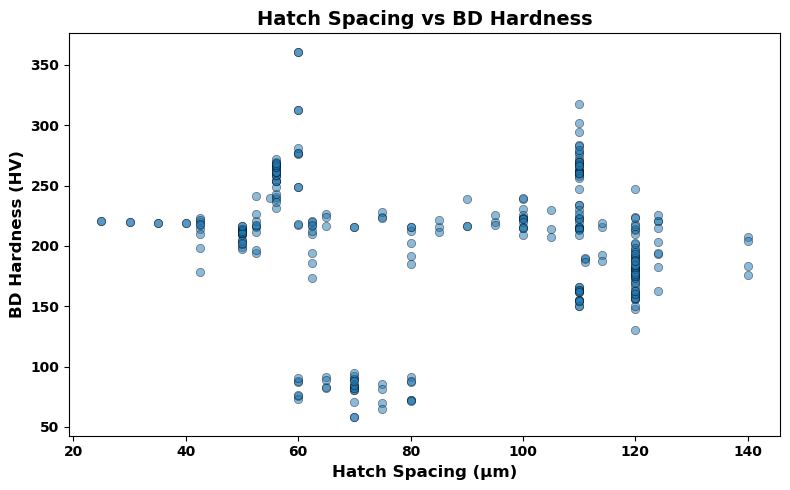

Hatch Spacing range: 25.0 - 140.0 µm
BD Hardness range: 57.89 - 361.06 HV

Highest hardness:
Hatch Spacing (um)     60.00
BD Hardness (HV)      361.06
Name: 754, dtype: float64

Lowest hardness:
Hatch Spacing (um)    70.00
BD Hardness (HV)      57.89
Name: 399, dtype: float64


In [31]:
# Scatter plot of Hatch Spacing (most influential feature) vs BD Hardness

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dataset['Hatch Spacing (um)'], dataset['BD Hardness (HV)'], alpha=0.5, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Hatch Spacing (µm)', fontsize=12, fontweight='bold')
ax.set_ylabel('BD Hardness (HV)', fontsize=12, fontweight='bold')
ax.set_title('Hatch Spacing vs BD Hardness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print extremes
df = dataset[['Hatch Spacing (um)', 'BD Hardness (HV)']].dropna()
print(f"Hatch Spacing range: {df['Hatch Spacing (um)'].min()} - {df['Hatch Spacing (um)'].max()} µm")
print(f"BD Hardness range: {df['BD Hardness (HV)'].min()} - {df['BD Hardness (HV)'].max()} HV")
print(f"\nHighest hardness:")
print(df.loc[df['BD Hardness (HV)'].idxmax()])
print(f"\nLowest hardness:")
print(df.loc[df['BD Hardness (HV)'].idxmin()])

TD HARDNESS - RANDOM FOREST WITH HYPERPARAMETER TUNING

Total samples: 82
Training: 65 | Test: 17
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best hyperparameters:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 300

RESULTS:
  Train R²:     0.8933
  Test R²:      0.7425
  Test RMSE:    14.22 HV
  Test MAE:     10.75 HV
  Overfitting:  0.1508

Top 5 Most Important Features:
  Layer Thickness (um)                     21.32%
  Volumetric energy density (J/mm3)        20.15%
  Scanning Speed (mm/s)                    15.69%
  Hatch Spacing (um)                       13.22%
  Strategy_Island                           9.72%


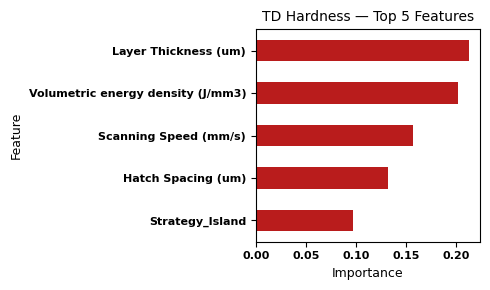

In [32]:
# TD Hardness - Random Forest with Hyperparameter Tuning
print("TD HARDNESS - RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*70)

# Prepare data
y_td = y_df['TD Hardness (HV)'].dropna()
X_td = x_df.loc[y_td.index]

print(f"\nTotal samples: {len(y_td)}")

# Split data
X_train_td, X_test_td, y_train_td, y_test_td = train_test_split(X_td, y_td, test_size=0.2, random_state=42)

print(f"Training: {len(X_train_td)} | Test: {len(X_test_td)}")

grid_search_td = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

grid_search_td.fit(X_train_td, y_train_td)

print("\nBest hyperparameters:")
for param, value in grid_search_td.best_params_.items():
    print(f"  {param}: {value}")

# Best model
rf_hardness_td = grid_search_td.best_estimator_

# Predictions
y_pred_train_td = rf_hardness_td.predict(X_train_td)
y_pred_test_td = rf_hardness_td.predict(X_test_td)

# Metrics
train_r2_td = r2_score(y_train_td, y_pred_train_td)
test_r2_td = r2_score(y_test_td, y_pred_test_td)
test_rmse_td = np.sqrt(mean_squared_error(y_test_td, y_pred_test_td))
test_mae_td = mean_absolute_error(y_test_td, y_pred_test_td)

print(f"\n{'='*70}")
print("RESULTS:")
print(f"{'='*70}")
print(f"  Train R²:     {train_r2_td:.4f}")
print(f"  Test R²:      {test_r2_td:.4f}")
print(f"  Test RMSE:    {test_rmse_td:.2f} HV")
print(f"  Test MAE:     {test_mae_td:.2f} HV")
print(f"  Overfitting:  {train_r2_td - test_r2_td:.4f}")

# Feature importance
print(f"\nTop 5 Most Important Features:")
feat_imp_td = pd.DataFrame({
    'Feature': X_td.columns,
    'Importance': rf_hardness_td.feature_importances_
}).sort_values('Importance', ascending=False)

for idx, row in feat_imp_td.head(5).iterrows():
    print(f"  {row['Feature']:40s} {row['Importance']*100:5.2f}%")

feat_imp_td.head(5).sort_values('Importance').plot.barh(x='Feature', y='Importance', color="#B91C1C", legend=False, figsize=(5,3))
plt.title('TD Hardness — Top 5 Features', fontsize=10)
plt.xlabel('Importance', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

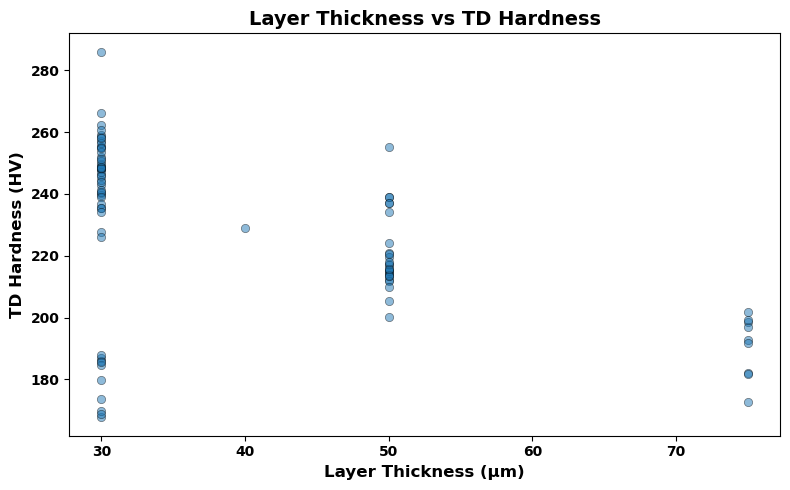

Layer Thickness range: 30.0 - 75.0 µm
TD Hardness range: 167.7 - 286.0 HV

Highest hardness:
Layer Thickness (um)     30.0
TD Hardness (HV)        286.0
Name: 799, dtype: float64

Lowest hardness:
Layer Thickness (um)     30.0
TD Hardness (HV)        167.7
Name: 689, dtype: float64


In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dataset['Layer Thickness (um)'], dataset['TD Hardness (HV)'], alpha=0.5, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Layer Thickness (µm)', fontsize=12, fontweight='bold')
ax.set_ylabel('TD Hardness (HV)', fontsize=12, fontweight='bold')
ax.set_title('Layer Thickness vs TD Hardness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print extremes
df = dataset[['Layer Thickness (um)', 'TD Hardness (HV)']].dropna()
print(f"Layer Thickness range: {df['Layer Thickness (um)'].min()} - {df['Layer Thickness (um)'].max()} µm")
print(f"TD Hardness range: {df['TD Hardness (HV)'].min()} - {df['TD Hardness (HV)'].max()} HV")
print(f"\nHighest hardness:")
print(df.loc[df['TD Hardness (HV)'].idxmax()])
print(f"\nLowest hardness:")
print(df.loc[df['TD Hardness (HV)'].idxmin()])

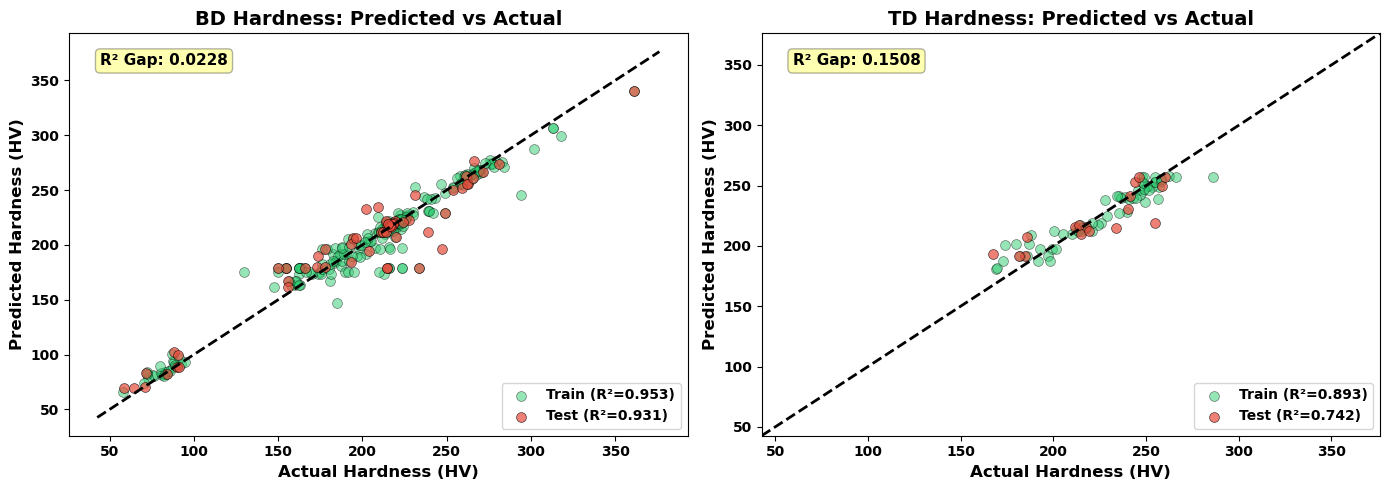

In [34]:
# Hardness Predictions vs Actuals prediction plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BD Hardness
ax1 = axes[0]
ax1.scatter(y_train_bd, y_pred_train_bd, alpha=0.5, s=50, 
           label=f'Train (R²={train_r2_bd:.3f})', color='#2ecc71', edgecolors='black', linewidth=0.5)
ax1.scatter(y_test_bd, y_pred_test_bd, alpha=0.7, s=50, 
           label=f'Test (R²={test_r2_bd:.3f})', color='#e74c3c', edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Actual Hardness (HV)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Hardness (HV)', fontsize=12, fontweight='bold')
ax1.set_title('BD Hardness: Predicted vs Actual', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.text(0.05, 0.95, f'R² Gap: {train_r2_bd - test_r2_bd:.4f}', transform=ax1.transAxes,
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# TD Hardness
ax2 = axes[1]
ax2.scatter(y_train_td, y_pred_train_td, alpha=0.5, s=50, 
           label=f'Train (R²={train_r2_td:.3f})', color='#2ecc71', edgecolors='black', linewidth=0.5)
ax2.scatter(y_test_td, y_pred_test_td, alpha=0.7, s=50, 
           label=f'Test (R²={test_r2_td:.3f})', color='#e74c3c', edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Actual Hardness (HV)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted Hardness (HV)', fontsize=12, fontweight='bold')
ax2.set_title('TD Hardness: Predicted vs Actual', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.text(0.05, 0.95, f'R² Gap: {train_r2_td - test_r2_td:.4f}', transform=ax2.transAxes,
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Set same scale
bd_data = np.concatenate([y_bd, y_pred_train_bd, y_pred_test_bd])
bd_min, bd_max = bd_data.min(), bd_data.max()
margin = (bd_max - bd_min) * 0.05
bd_lim = [bd_min - margin, bd_max + margin]

ax1.plot(bd_lim, bd_lim, 'k--', linewidth=2, label='Perfect Prediction')
ax2.plot(bd_lim, bd_lim, 'k--', linewidth=2, label='Perfect Prediction')
ax2.set_xlim(bd_lim)
ax2.set_ylim(bd_lim)

plt.tight_layout()
plt.show()

# Input - Yield stress

BD YIELD STRESS
Samples: 327, Features: 8
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best hyperparameters:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Top 5 Features:
  Layer Thickness (um)                36.37%
  Scanning Speed (mm/s)               22.46%
  Volumetric energy density (J/mm3)   22.16%
  Laser Power (W)                      8.53%
  Hatch Spacing (um)                   5.23%


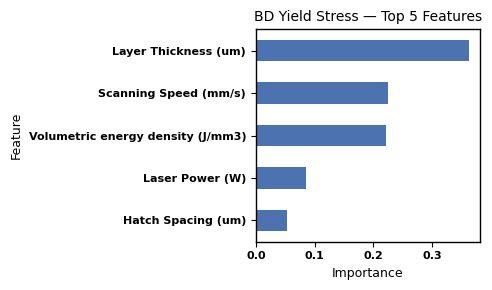


Results:
  Train R²: 0.8755
  Test R²:  0.7503
  Test RMSE: 77.02 MPa


In [38]:
# BD Yield Stress - Random Forest with Hyperparameter Tuning
# Baseline: Process Parameters Only
print("BD YIELD STRESS")
print("="*70)

# Prepare data
y_ys_bd = y_df['BD Yield Stress (MPa)'].dropna()
X_ys_bd_baseline = x_df.loc[y_ys_bd.index]

print(f"Samples: {len(y_ys_bd)}, Features: {X_ys_bd_baseline.shape[1]}")

# Split data
X_train_bd_bl, X_test_bd_bl, y_train_bd_bl, y_test_bd_bl = train_test_split(X_ys_bd_baseline, y_ys_bd, test_size=0.2, random_state=42)

grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                   param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_bd_bl, y_train_bd_bl)

rf_ys_bd_baseline = grid.best_estimator_

print("\nBest hyperparameters:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate
train_r2_bd_bl = r2_score(y_train_bd_bl, rf_ys_bd_baseline.predict(X_train_bd_bl))
test_r2_bd_bl = r2_score(y_test_bd_bl, rf_ys_bd_baseline.predict(X_test_bd_bl))
test_rmse_bd_bl = np.sqrt(mean_squared_error(y_test_bd_bl, rf_ys_bd_baseline.predict(X_test_bd_bl)))

# Feature importance
print(f"\nTop 5 Features:")
feat_imp_bd = pd.DataFrame({
    'Feature': X_ys_bd_baseline.columns,
    'Importance': rf_ys_bd_baseline.feature_importances_
}).sort_values('Importance', ascending=False).head(5)

for _, row in feat_imp_bd.iterrows():
    print(f"  {row['Feature']:35s} {row['Importance']*100:5.2f}%")

fig, ax = plt.subplots(figsize=(5, 3))
feat_imp_bd.head(5).sort_values('Importance').plot.barh(x='Feature', y='Importance', color='#4c72b0', legend=False, ax=ax)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

ax.set_title('BD Yield Stress — Top 5 Features', fontsize=10)
ax.set_xlabel('Importance', fontsize=9)
ax.set_ylabel('Feature', fontsize=9)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

print(f"\nResults:")
print(f"  Train R²: {train_r2_bd_bl:.4f}")
print(f"  Test R²:  {test_r2_bd_bl:.4f}")
print(f"  Test RMSE: {test_rmse_bd_bl:.2f} MPa")

TD YIELD STRESS
Samples: 71, Features: 8
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best hyperparameters:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Top 5 Features:
  Scanning Speed (mm/s)               34.19%
  Volumetric energy density (J/mm3)   26.62%
  Layer Thickness (um)                11.79%
  Strategy_Meander                    10.97%
  Laser Power (W)                      8.60%


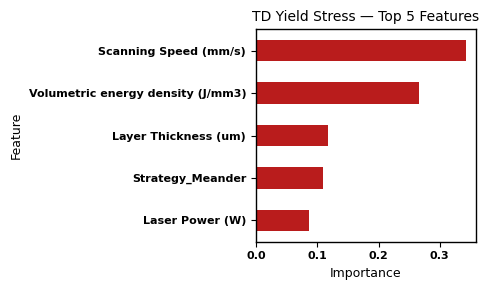


Results:
  Train R²: 0.8217
  Test R²:  0.2636
  Test RMSE: 94.65 MPa


In [39]:
# TD Yield Stress - Random Forest with Hyperparameter Tuning
# Baseline: Process Parameters Only
print("TD YIELD STRESS")
print("="*70)

# Prepare data
y_ys_td = y_df['TD Yield Stress (MPa)'].dropna()
X_ys_td_baseline = x_df.loc[y_ys_td.index]

print(f"Samples: {len(y_ys_td)}, Features: {X_ys_td_baseline.shape[1]}")

# Split
X_train_td_bl, X_test_td_bl, y_train_td_bl, y_test_td_bl = train_test_split(X_ys_td_baseline, y_ys_td, test_size=0.35, random_state=42)

grid_td = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                      param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_td.fit(X_train_td_bl, y_train_td_bl)

rf_ys_td_baseline = grid_td.best_estimator_

print("\nBest hyperparameters:")
for param, value in grid_td.best_params_.items():
    print(f"  {param}: {value}")

# Feature importance
print(f"\nTop 5 Features:")
feat_imp_td = pd.DataFrame({
    'Feature': X_ys_td_baseline.columns,
    'Importance': rf_ys_td_baseline.feature_importances_
}).sort_values('Importance', ascending=False).head(5)

for _, row in feat_imp_td.iterrows():
    print(f"  {row['Feature']:35s} {row['Importance']*100:5.2f}%")

fig, ax = plt.subplots(figsize=(5, 3))
feat_imp_td.head(5).sort_values('Importance').plot.barh(x='Feature', y='Importance', color='#B91C1C', legend=False, ax=ax)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

ax.set_title('TD Yield Stress — Top 5 Features', fontsize=10)
ax.set_xlabel('Importance', fontsize=9)
ax.set_ylabel('Feature', fontsize=9)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

# Evaluate
train_r2_td_bl = r2_score(y_train_td_bl, rf_ys_td_baseline.predict(X_train_td_bl))
test_r2_td_bl = r2_score(y_test_td_bl, rf_ys_td_baseline.predict(X_test_td_bl))
test_rmse_td_bl = np.sqrt(mean_squared_error(y_test_td_bl, rf_ys_td_baseline.predict(X_test_td_bl)))

print(f"\nResults:")
print(f"  Train R²: {train_r2_td_bl:.4f}")
print(f"  Test R²:  {test_r2_td_bl:.4f}")
print(f"  Test RMSE: {test_rmse_td_bl:.2f} MPa")

In [ ]:
td_both = pd.DataFrame({
    'TD Hardness (HV)': y_df['TD Hardness (HV)'],
    'TD Yield Stress (MPa)': y_df['TD Yield Stress (MPa)']
}).dropna()

print(f"Samples with BOTH TD Hardness AND TD Yield Stress: {len(td_both)}")

Samples with BOTH TD Hardness AND TD Yield Stress: 1


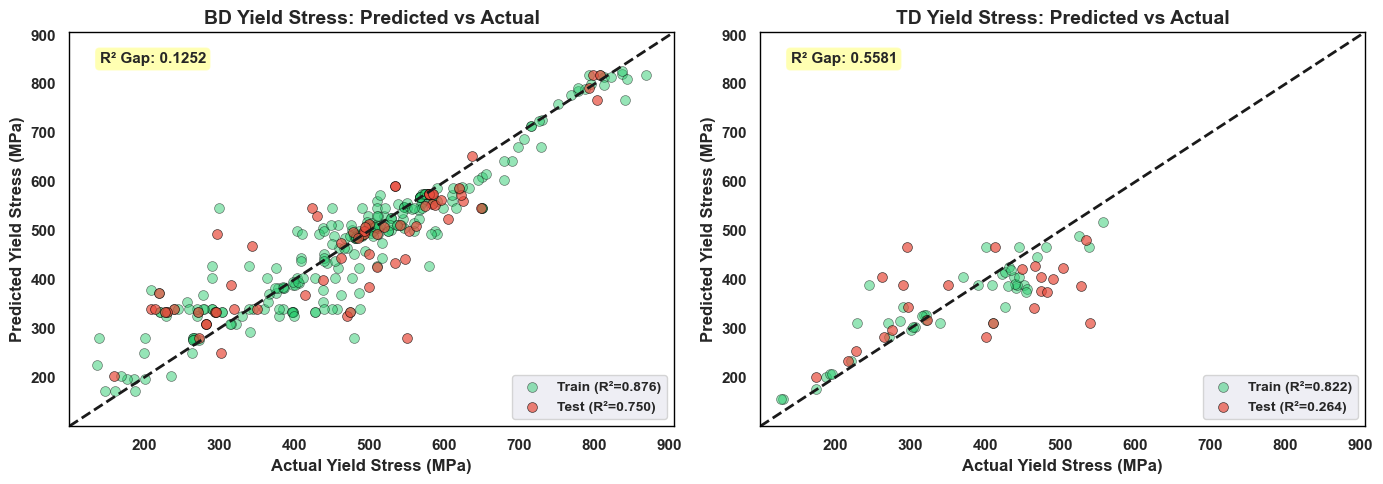

In [63]:
# Yield Stress Predictions vs Actuals prediction plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BD Yield Stress
ax1 = axes[0]
ax1.scatter(y_train_bd_bl, rf_ys_bd_baseline.predict(X_train_bd_bl), alpha=0.5, s=50,
            label=f'Train (R²={train_r2_bd_bl:.3f})', color='#2ecc71', edgecolors='black', linewidth=0.5)
ax1.scatter(y_test_bd_bl, rf_ys_bd_baseline.predict(X_test_bd_bl), alpha=0.7, s=50,
            label=f'Test (R²={test_r2_bd_bl:.3f})', color='#e74c3c', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Actual Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax1.set_title('BD Yield Stress: Predicted vs Actual', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.text(0.05, 0.95, f'R² Gap: {train_r2_bd_bl - test_r2_bd_bl:.4f}', transform=ax1.transAxes,
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# TD Yield Stress
ax2 = axes[1]
ax2.scatter(y_train_td_bl, rf_ys_td_baseline.predict(X_train_td_bl), alpha=0.5, s=50,
            label=f'Train (R²={train_r2_td_bl:.3f})', color='#2ecc71', edgecolors='black', linewidth=0.5)
ax2.scatter(y_test_td_bl, rf_ys_td_baseline.predict(X_test_td_bl), alpha=0.7, s=50,
            label=f'Test (R²={test_r2_td_bl:.3f})', color='#e74c3c', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Actual Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax2.set_title('TD Yield Stress: Predicted vs Actual', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.text(0.05, 0.95, f'R² Gap: {train_r2_td_bl - test_r2_td_bl:.4f}', transform=ax2.transAxes,
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Set same scale
bd_ys_data = np.concatenate([y_train_bd_bl.values, y_test_bd_bl.values,
                              rf_ys_bd_baseline.predict(X_train_bd_bl),
                              rf_ys_bd_baseline.predict(X_test_bd_bl)])
bd_ys_min, bd_ys_max = bd_ys_data.min(), bd_ys_data.max()
margin = (bd_ys_max - bd_ys_min) * 0.05
bd_ys_lim = [bd_ys_min - margin, bd_ys_max + margin]

ax1.plot(bd_ys_lim, bd_ys_lim, 'k--', linewidth=2, label='Perfect Prediction')
ax2.plot(bd_ys_lim, bd_ys_lim, 'k--', linewidth=2, label='Perfect Prediction')
ax1.set_xlim(bd_ys_lim)
ax1.set_ylim(bd_ys_lim)
ax2.set_xlim(bd_ys_lim)
ax2.set_ylim(bd_ys_lim)
for ax in [ax1, ax2]:
    ax.set_facecolor('white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

# Input - Hardness - Yield Stress

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("="*70)
print("HARDNESS-TO-YS MODELS WITH PROPER HYPERPARAMETER TUNING")
print("="*70)

# Hyperparameter grid
param_grid_h2ys = {
    'n_estimators': np.linspace(100, 300, 10, dtype=int),
    'max_depth': np.linspace(3, 10, 7, dtype=int),
    'min_samples_split': np.linspace(10, 30, 5, dtype=int),
    'min_samples_leaf': np.linspace(5, 15, 5, dtype=int)
}

# BD: Hardness → Yield Stress
print("\n1. BD Hardness → BD Yield Stress")
y_ys_bd_all = y_df['BD Yield Stress (MPa)'].dropna()
X_params_bd_all = x_df.loc[y_ys_bd_all.index]
pred_bd_hardness_all = rf_hardness_bd.predict(X_params_bd_all)

print(f"   Total samples: {len(y_ys_bd_all)}")

X_train_bd, X_test_bd, y_train_bd, y_test_bd = train_test_split(
    pred_bd_hardness_all.reshape(-1, 1),
    y_ys_bd_all,
    test_size=0.2,
    random_state=42
)

print(f"   Training: {len(X_train_bd)} | Test: {len(X_test_bd)}")

# GridSearchCV
grid_bd_h2ys = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_h2ys,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_bd_h2ys.fit(X_train_bd, y_train_bd)

print(f"\n   Best hyperparameters:")
for param, value in grid_bd_h2ys.best_params_.items():
    print(f"     {param}: {value}")

# Best model
rf_bd_h2ys = grid_bd_h2ys.best_estimator_

# Evaluate on train and test
train_r2_bd = rf_bd_h2ys.score(X_train_bd, y_train_bd)
test_r2_bd = rf_bd_h2ys.score(X_test_bd, y_test_bd)
test_rmse_bd = np.sqrt(mean_squared_error(y_test_bd, rf_bd_h2ys.predict(X_test_bd)))

print(f"\n   Results:")
print(f"     Train R²: {train_r2_bd:.4f}")
print(f"     Test R²:  {test_r2_bd:.4f}")
print(f"     Test RMSE: {test_rmse_bd:.2f} MPa")
print(f"     Overfitting gap: {train_r2_bd - test_r2_bd:.4f}")



HARDNESS-TO-YS MODELS WITH PROPER HYPERPARAMETER TUNING

1. BD Hardness → BD Yield Stress
   Total samples: 327
   Training: 261 | Test: 66

   Best hyperparameters:
     max_depth: 10
     min_samples_leaf: 5
     min_samples_split: 10
     n_estimators: 122

   Results:
     Train R²: 0.5393
     Test R²:  0.4716
     Test RMSE: 112.04 MPa
     Overfitting gap: 0.0677


In [41]:
# TD: Hardness → Yield Stress
print("\n2. TD Hardness → TD Yield Stress")
y_ys_td_all = y_df['TD Yield Stress (MPa)'].dropna()
X_params_td_all = x_df.loc[y_ys_td_all.index]
pred_td_hardness_all = rf_hardness_td.predict(X_params_td_all)

print(f"   Total samples: {len(y_ys_td_all)}")

X_train_td, X_test_td, y_train_td, y_test_td = train_test_split(
    pred_td_hardness_all.reshape(-1, 1),
    y_ys_td_all,
    test_size=0.3,
    random_state=42
)

print(f"   Training: {len(X_train_td)} | Test: {len(X_test_td)}")

# GridSearchCV
grid_td_h2ys = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_h2ys,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_td_h2ys.fit(X_train_td, y_train_td)

print(f"\n   Best hyperparameters:")
for param, value in grid_td_h2ys.best_params_.items():
    print(f"     {param}: {value}")

# Best model
rf_td_h2ys = grid_td_h2ys.best_estimator_

# Evaluate on train and test
train_r2_td = rf_td_h2ys.score(X_train_td, y_train_td)
test_r2_td = rf_td_h2ys.score(X_test_td, y_test_td)
test_rmse_td = np.sqrt(mean_squared_error(y_test_td, rf_td_h2ys.predict(X_test_td)))

print(f"\n   Results:")
print(f"     Train R²: {train_r2_td:.4f}")
print(f"     Test R²:  {test_r2_td:.4f}")
print(f"     Test RMSE: {test_rmse_td:.2f} MPa")
print(f"     Overfitting gap: {train_r2_td - test_r2_td:.4f}")

print("\n" + "="*70)
print("SUMMARY H2YS MODELS")
print("="*70)
print(f"BD: Test R² = {test_r2_bd:.4f}, RMSE = {test_rmse_bd:.2f} MPa")
print(f"TD: Test R² = {test_r2_td:.4f}, RMSE = {test_rmse_td:.2f} MPa")


2. TD Hardness → TD Yield Stress
   Total samples: 71
   Training: 49 | Test: 22

   Best hyperparameters:
     max_depth: 5
     min_samples_leaf: 5
     min_samples_split: 10
     n_estimators: 277

   Results:
     Train R²: 0.4147
     Test R²:  0.1361
     Test RMSE: 98.45 MPa
     Overfitting gap: 0.2786

SUMMARY H2YS MODELS
BD: Test R² = 0.4716, RMSE = 112.04 MPa
TD: Test R² = 0.1361, RMSE = 98.45 MPa


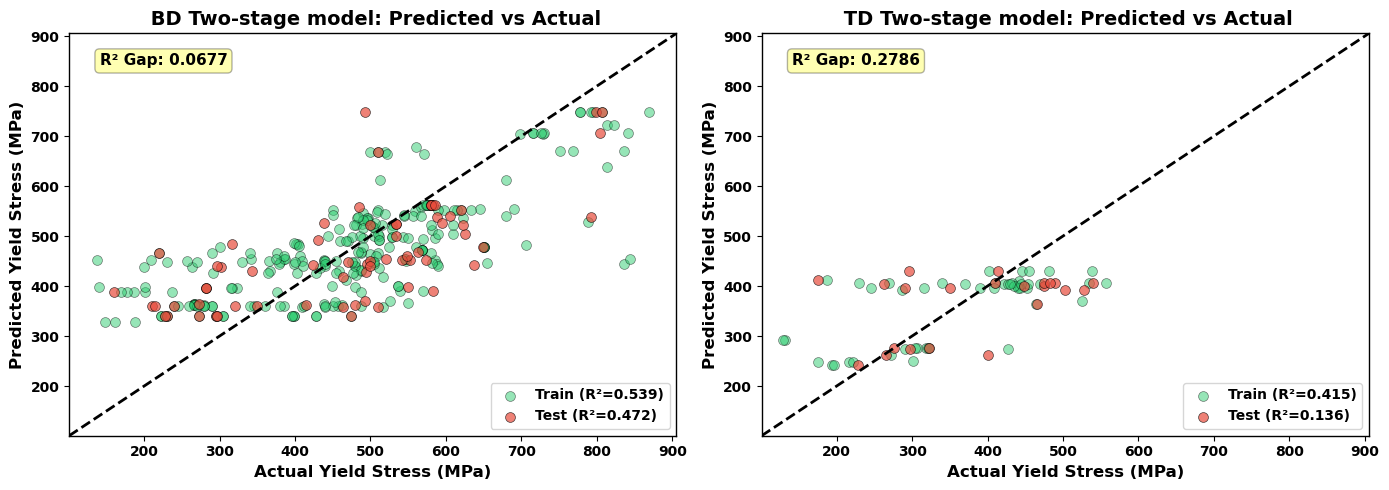

In [42]:
# Two stage: input → Hardness → Yield Stress Predictions vs Actuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BD Input → Hardness → Yield Stress
ax1 = axes[0]
ax1.scatter(y_train_bd, rf_bd_h2ys.predict(X_train_bd), alpha=0.5, s=50,
            label=f'Train (R²={train_r2_bd:.3f})', color='#2ecc71', edgecolors='black', linewidth=0.5)
ax1.scatter(y_test_bd, rf_bd_h2ys.predict(X_test_bd), alpha=0.7, s=50,
            label=f'Test (R²={test_r2_bd:.3f})', color='#e74c3c', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Actual Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax1.set_title(' BD Two-stage model: Predicted vs Actual', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.text(0.05, 0.95, f'R² Gap: {train_r2_bd - test_r2_bd:.4f}', transform=ax1.transAxes,
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# TD input → Hardness → Yield Stress
ax2 = axes[1]
ax2.scatter(y_train_td, rf_td_h2ys.predict(X_train_td), alpha=0.5, s=50,
            label=f'Train (R²={train_r2_td:.3f})', color='#2ecc71', edgecolors='black', linewidth=0.5)
ax2.scatter(y_test_td, rf_td_h2ys.predict(X_test_td), alpha=0.7, s=50,
            label=f'Test (R²={test_r2_td:.3f})', color='#e74c3c', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Actual Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted Yield Stress (MPa)', fontsize=12, fontweight='bold')
ax2.set_title(' TD Two-stage model: Predicted vs Actual', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.text(0.05, 0.95, f'R² Gap: {train_r2_td - test_r2_td:.4f}', transform=ax2.transAxes,
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Set same scale
h2ys_data = np.concatenate([y_train_bd.values, y_test_bd.values,
                             rf_bd_h2ys.predict(X_train_bd),
                             rf_bd_h2ys.predict(X_test_bd)])
h2ys_min, h2ys_max = h2ys_data.min(), h2ys_data.max()
margin = (h2ys_max - h2ys_min) * 0.05
h2ys_lim = [h2ys_min - margin, h2ys_max + margin]

ax1.plot(h2ys_lim, h2ys_lim, 'k--', linewidth=2, label='Perfect Prediction')
ax2.plot(h2ys_lim, h2ys_lim, 'k--', linewidth=2, label='Perfect Prediction')
ax1.set_xlim(h2ys_lim)
ax1.set_ylim(h2ys_lim)
ax2.set_xlim(h2ys_lim)
ax2.set_ylim(h2ys_lim)

for ax in [ax1, ax2]:
    ax.set_facecolor('white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)
        
plt.tight_layout()
plt.show()

In [68]:
from ipywidgets import interact, FloatSlider, Dropdown
import ipywidgets as widgets

def predict_properties(laser_power, scanning_speed, layer_thickness, 
                       hatch_spacing, scanning_strategy):
    
    vol_energy = laser_power / (scanning_speed * layer_thickness * hatch_spacing / 1000000)
    
    new_params = {
        'Laser Power (W)': laser_power,
        'Scanning Speed (mm/s)': scanning_speed,
        'Layer Thickness (um)': layer_thickness,
        'Hatch Spacing (um)': hatch_spacing,
        'Volumetric energy density (J/mm3)': vol_energy,
        'Scanning strategy': scanning_strategy
    }
    
    input_df = pd.DataFrame([new_params])
    input_df['Scanning strategy'] = input_df['Scanning strategy'].str.title()
    
    strategy_dummies = pd.get_dummies(input_df['Scanning strategy'], prefix='Strategy')
    for col in ['Strategy_Island', 'Strategy_Meander', 'Strategy_Stripe']:
        if col not in strategy_dummies.columns:
            strategy_dummies[col] = 0
    
    input_df = pd.concat([input_df, strategy_dummies], axis=1)
    input_df = input_df.drop('Scanning strategy', axis=1)
    input_df = input_df[X_bd.columns]
    
    if 'rf_hardness_bd' in globals() and 'rf_hardness_td' in globals():
        # Stage 1: Predict Hardness
        bd_hardness_pred = rf_hardness_bd.predict(input_df)[0]
        td_hardness_pred = rf_hardness_td.predict(input_df)[0]
        
        # Stage 2: Predict Yield Stress from predicted hardness
        bd_ys_pred = None
        td_ys_pred = None
        
        if 'rf_bd_h2ys' in globals():
            bd_ys_pred = rf_bd_h2ys.predict([[bd_hardness_pred]])[0]
        
        if 'rf_td_h2ys' in globals():
            td_ys_pred = rf_td_h2ys.predict([[td_hardness_pred]])[0]
        
        # Display results
        print("="*60)
        print("INPUT PARAMETERS")
        print("="*60)
        print(f"Laser Power:              {laser_power:.1f} W")
        print(f"Scanning Speed:           {scanning_speed:.1f} mm/s")
        print(f"Layer Thickness:          {layer_thickness:.1f} μm")
        print(f"Hatch Spacing:            {hatch_spacing:.1f} μm")
        print(f"Scanning Strategy:        {scanning_strategy}")
        print(f"Vol. Energy Density:      {vol_energy:.2f} J/mm³")
        
        print("\n" + "="*60)
        print("PREDICTED HARDNESS")
        print("="*60)
        print(f"BD Hardness:              {bd_hardness_pred:.2f} HV")
        print(f"TD Hardness:              {td_hardness_pred:.2f} HV")
        print(f"Difference:               {abs(bd_hardness_pred - td_hardness_pred):.2f} HV")
        
        if bd_ys_pred is not None and td_ys_pred is not None:
            print("\n" + "="*60)
            print("PREDICTED YIELD STRESS")
            print("="*60)
            print(f"BD Yield Stress:          {bd_ys_pred:.2f} MPa")
            print(f"TD Yield Stress:          {td_ys_pred:.2f} MPa")
            print(f"Difference:               {abs(bd_ys_pred - td_ys_pred):.2f} MPa")
        
        print("="*60)

interact(
    predict_properties,
    laser_power=FloatSlider(value=200, min=50, max=400, step=10, description='Laser Power (W):'),
    scanning_speed=FloatSlider(value=1000, min=100, max=3000, step=50, description='Scanning Speed:'),
    layer_thickness=FloatSlider(value=30, min=10, max=100, step=5, description='Layer Thickness:'),
    hatch_spacing=FloatSlider(value=100, min=50, max=200, step=5, description='Hatch Spacing:'),
    scanning_strategy=Dropdown(options=['Meander', 'Island', 'Stripe'], 
                               value='Meander', description='Strategy:')
)

interactive(children=(FloatSlider(value=200.0, description='Laser Power (W):', max=400.0, min=50.0, step=10.0)…

<function __main__.predict_properties(laser_power, scanning_speed, layer_thickness, hatch_spacing, scanning_strategy)>